This notebook is used to walk through building up an MAE using a subset of the Dec 17, 2023 Nore'easter data. Data is 239 images from epoch num: 1702827001820. The data was made in metashape using the most recent method of using camera extrinsics. 

The first iteration of the model uses only 1 transect in time for training and testing data. Then the model builds up to use the whole spatial extent of the DEM for training data, while predicting on the same transect in each iteration.

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
import os
import glob
import mat73

from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, losses
#from tensorflow.keras.datasets import fashion_mnist (fake data)
from tensorflow.keras.models import Model
from PIL import Image
from scipy.io import loadmat

In [21]:
# paths
MAE_datapath=r"/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data"
rawdatapath=r"/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/videos/Transect_y7_3/2yavg/transects_7.3_2.mat"
traindatapath=r"/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/videos/1702827001820_transects.mat" # change this
savepath=r"/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/Figures/R2L_results_prelim/building_up/iteration1"

Load and prep data

In [22]:
# load in matfile and convert
raw_transects=loadmat(rawdatapath)
transects=raw_transects['ztran']
transect_df_raw=pd.DataFrame(transects) # convert to dataframe
print(transect_df_raw.shape)

(551, 239)


In [23]:
raw_mat=loadmat(traindatapath)
train_struct=raw_mat['all_trans_struct']

all_trans=[]
names=[]

for elem in train_struct.ravel():
    name=elem['name'].item()
    data_matrix=elem['data']

    temp_df=pd.DataFrame(data_matrix)
    temp_df['name']=name

    all_trans.append(temp_df)
    names.append(name)

        
train_trans_df=pd.concat(all_trans,axis=0,keys=names, names=['transect_name','original_index'])
train_ds=train_trans_df.drop(columns=['name'])
print("Dataset Shape:", train_ds.shape)
print("\nFirst few rows of the Transect Dataframe:")
print(train_ds.head())


Dataset Shape: (23142, 239)

First few rows of the Transect Dataframe:
                              0    1    2    3    4    5    6    7    8    \
transect_name original_index                                                
transect_y-60 0               NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
              1               NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
              2               NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
              3               NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
              4               NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   

                              9    ...  229  230  231  232  233  234  235  \
transect_name original_index       ...                                      
transect_y-60 0               NaN  ...  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
              1               NaN  ...  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
              2               NaN  ...  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
    

In [24]:
# need to make transect and training data normalized on the same scale
from sklearn.preprocessing import MinMaxScaler
global_scaler=MinMaxScaler()
combined_raw_data=pd.concat([transect_df_raw,train_ds],axis=0)
global_scaler.fit(combined_raw_data.values.reshape(-1,1))
#function to transform ds
def scale_dataframe(df,fitted_scalar):
    scaled_matrix=df.values.copy()
    gaps_mask=np.isnan(scaled_matrix)

    flat_vals=scaled_matrix.reshape(-1,1)
    flat_vals[~np.isnan(flat_vals)]=fitted_scalar.transform(flat_vals[~np.isnan(flat_vals)].reshape(-1,1)).flatten()
    scaled_df=pd.DataFrame(flat_vals.reshape(df.shape),columns=df.columns,index=df.index)
    return scaled_df

train_df_norm=scale_dataframe(train_ds,global_scaler)
train_df_norm_nodune=train_df_norm.iloc[200:,:]

transect_73=scale_dataframe(transect_df_raw,global_scaler)
transect_73_nodune=transect_73.iloc[200:,:]
#transect_df_norm=scale_dataframe(transect_df_raw,global_scaler)
#transect_df_norm_nodune=transect_df_norm[200:]
#train_df_norm=scale_dataframe(train_ds,global_scaler)
#train_df_norm_nodune=train_df_norm[200:]

In [25]:
def unscale_dataframe(df, fitted_scalar):
    # Retrieve original values
    scaled_matrix = df.values 
    
    # Inverse transform the entire matrix (NaNs are ignored by the scaler automatically)
    unscaled_matrix = fitted_scalar.inverse_transform(scaled_matrix)
    
    # Reconstruct the DataFrame
    unscaled_df = pd.DataFrame(unscaled_matrix, columns=df.columns, index=df.index)
    
    return unscaled_df

In [26]:
print(transect_73_nodune.shape)

(351, 239)


In [27]:
df=transect_73
df_un_norm=transect_df_raw
df.to_csv("/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/R2L_buildingUp/transect7_3_norm.csv",index=False)
df_un_norm.to_csv("/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/R2L_buildingUp/transect_7_3.csv",index=False)

ITERATION 1: Using 1 transect for training, testing, and MAE reconstruction

In [28]:
# define model
# right now using a window length of 10 so need to build up back to 10, if size is a multiple of 8 it's much easier for building up
class Denoise(Model):
    def __init__(self,window_size):
        super(Denoise,self).__init__()
        self.window_size=window_size

        self.encoder=tf.keras.Sequential([
            layers.Input(shape=(window_size,2)), # changed from none
            layers.Conv1D(32,3,activation='relu',padding='same',strides=2),
            layers.Conv1D(16,3,activation='relu',padding='same',strides=2),
            layers.Conv1D(8,3,activation='relu',padding='same',strides=2) #maintain shape with strides=1
        ])

        self.decoder=tf.keras.Sequential([
            layers.Conv1DTranspose(8,3,strides=2,activation='relu',padding='same'),
            layers.Conv1DTranspose(16,3,strides=2,activation='relu',padding='same'),
            layers.Conv1DTranspose(32,3,strides=2,activation='relu',padding='same'),
            layers.Flatten(),
            layers.Dense(window_size,activation='sigmoid'),
            layers.Reshape((window_size,1))
            #layers.Conv1D(1,3,activation='sigmoid',padding='same'), #normalized output
            #layers.Cropping1D((0,6)) # builds up to 16, need length of 10
            #x=layers.Dense(10,activation='sigmoid')(x) 
        ])

    def call(self,x):
        encoded=self.encoder(x)
        decoded=self.decoder(encoded)
        return decoded
    
    def train_step(self,data):
        # to get input tensor (x_input,y) from .map() in mask
        x_input,y, mask,start_idx,t_step = data #(batch,10,2) (batch,10,1) (batch,10,1)

        #x_input,mask=masking_layer(x) # apply mask
        #x_masked=x_input[:,:,:2]
        with tf.GradientTape() as tape: 
            # forward pass using x_masked
            y_pred=self(x_input,training=True)
            # calc loss
            #mask=x_input[:,:,1:2] #grab mask from 2nd channel
            mse=tf.square(y_pred-y) #calc loss
            masked_mse=mse*(1.0 - mask) # masked loss
            loss=tf.reduce_sum(masked_mse)/(tf.reduce_sum(1.0-mask)+1e-1)
            #base_loss=tf.reduce_sum(masked_mse)/(tf.reduce_sum(1.0-mask)+1e-6) # mean sq error over just masked points
            # edge matching loss
            #mask_diff=tf.abs(mask[:,1:,:] - mask[:,:-1,:]) # find exact edge indices
            #edge_weights=tf.pad(mask_diff,[[0,0],[1,0],[0,0]]) # back to full shape
            #edge_loss=tf.reduce_sum(mse*edge_weights)/(tf.reduce_sum(edge_weights)+1e-6)

            # combined loss
            #total_loss=base_loss+(2*edge_loss) # heavy emphasis on matching uo edges
        trainable_vars=self.trainable_variables
        gradients=tape.gradient(loss,trainable_vars)
        self.optimizer.apply_gradients(zip(gradients,trainable_vars))

        return{"loss":loss}
    
    def test_step(self,data):
         # to get input tensor
        x,y,mask,start_idx,t_step=data
        
        #x_input,mask=masking_layer(x) # apply mask
        #x_masked=x_input[:,:,:2]
        y_pred=self(x,training=False)

        #mask=x_input[:,:,1:2]
        mse=tf.square(y_pred-y) #calc loss
        masked_mse=mse*(1.0 - mask) # masked loss
        loss=tf.reduce_sum(masked_mse)/(tf.reduce_sum(1.0-mask)+1e-6) # mean sq error over just masked points

        return {"loss":loss}
        

    
#autoencoder=Denoise()
#autoencoder.compile(optimizer='adam',loss='mse')

def gap_mask(x,mask_ratio):
     #batch_size=tf.shape(x)[0]
     length=tf.shape(x)[0]# number of things in x, x is (10,1)

     gap_size=tf.cast(tf.cast(length,tf.float32)*mask_ratio,tf.int32) # how many elements to be masked (length of window*maskratio)
     gap_size=tf.maximum(gap_size,1) # no zero lengths aka at least one thing is masked
     max_start=tf.maximum(length-gap_size,0) #mask starts inside window

     start=tf.random.uniform([],minval=0,maxval=max_start+1,dtype=tf.int32) # random start of mask

     #mask=tf.ones_like((batch_size,length,1),dtype=tf.float32) # 1D mask (batch,length,1)

     #idx=tf.range(start,start+gap_size) # gap indices
     #idx=tf.expand_dims(idx,axis=1) #add dimension (block_size,1)
     range_idx=tf.range(length) # (length,) 
     #range_idx=tf.expand_dims(range_idx,0) #(1,length)
     #range_idx=tf.tile(range_idx,[batch_size,1]) # (batch, length)

     #start_extra_dim=tf.reshape(start,[batch_size,1]) # (batch,1)
     #boolean mask
     if_in_gap=tf.logical_and(range_idx>=start,range_idx<(start+gap_size))

     gap_mask_tensor=tf.cast(if_in_gap,tf.float32)
     gap_mask_tensor=tf.expand_dims(gap_mask_tensor,-1) # 1 at gap, 0 everywhere else (batch,length,1)
     mask=1-gap_mask_tensor
     #mask=1-tf.expand_dims(tf.cast(if_in_gap,tf.float32),axis=-1)# 0 is gap 1 is not (batch,length,1)
    
     #updates=tf.zeros((batch_size,gap_size,1),dtype=tf.float32)# zeros at made gaps
     #mask=tf.tensor_scatter_nd_update(mask,idx,updates)

     #batch_idx=tf.range(batch_size)
     #batch_idx=tf.expand_dims(batch_idx,-1) # (batch,1)
     #atch_idx=tf.tile(batch_idx,[1,gap_size]) # (batch,gap_size)

     #seq_idx=tf.tile(tf.expand_dims(idx,0),[batch_size,1]) #(batch, gap_size)

     #ndx=tf.stack([batch_idx,seq_idx],axis=-1) # (batch, gap_size, 2)

     #mask=tf.tensor_scatter_nd_update(mask,indx,updates)
     
     x_masked=x*mask
     return x_masked,mask

def random_mask(x,mask_ratio):
    #batch=tf.shape(x)[0]
    #length=tf.shape(x)[1]
    #shape=[tf.shape(x)[0],tf.shape(x)[1],1] # list [batch,length,1]
    mask=tf.cast(tf.random.uniform(tf.shape(x))>mask_ratio,tf.float32) # mask is is (batch,length,1) and x_masked is (batch,length,2)
    x_masked=x*mask
    return x_masked, mask


def masking_layer(x,start,t_step):
    #x=tf.expand_dims(x,axis=-1) if len(x.shape)==1 else x # (length,1)
    window_size=tf.shape(x)[0]
    #x=tf.expand_dims(x,axis=-1) if len(x.shape)==1 else x #check right shape or add dimension (length,1)
    #x=tf.expand_dims(x,axis=0) #(1,length)
    #x=tf.convert_to_tensor(x)
    x=tf.reshape(tf.cast(x,tf.float32),[window_size,1]) # 10 is window length
    mask_ratio=tf.random.uniform([],0.1,0.8) #mask possibilities of 10-80%

    use_gaps=tf.random.uniform([])<0.7 #random chosen number to use this mask method
    #mask via gap and random method
    x_masked,mask=tf.cond(use_gaps,lambda: gap_mask(x,mask_ratio),lambda: random_mask(x,mask_ratio))

    #x_masked=tf.convert_to_tensor(x_masked)
    #mask=tf.convert_to_tensor(mask)
    # mask as a second channel
    #if mask.shape.rank==1:
        #mask=tf.expand_dims(mask,axis=1)
    #mask=tf.tile(mask,[1,10,1])
    #mask.set_shape([10,1])
    #x_masked.set_shape([10,1])
    x_input=tf.concat([x_masked,mask],axis=-1) # now (1,length,2)

    #tf.print("running mask layer- x_masked shape:", tf.shape(x_masked))
    #tf.print("running masked layer- mask shape:", tf.shape(mask))


    return x_input,x, mask, start, t_step# (given data and target/real og data)


In [29]:
def window_split_rtl(start, stop, window_size, overlap_stride):
    windows = []
    
    # Start at the absolute right-most possible window position
    current_start = stop - window_size
    
    # Loop backwards as long as the window doesn't cross the left 'start' boundary
    while current_start >= start:
        w_start = current_start
        w_stop = current_start + window_size
        
        # Option A: Append as (start, stop) so indices read normally
        windows.append((w_start, w_stop))
        
        # Move the window stride to the left
        current_start -= overlap_stride

    # Optional: If you want the final list to order from right-to-left,
    # it naturally will (e.g., [(90, 100), (80, 90)...]).
    return windows

In [30]:
def find_windows_of_data(df, window_size, overlap_stride):
    # Find the continuous sections of data and extract window indices
    window_idx = {}
    for timestep, transect in df.items():
        arg = transect.values
        masked = np.ma.masked_invalid(arg)
        clumps = np.ma.clump_unmasked(masked)
        window_idx[timestep] = [(s.start, s.stop) for s in clumps]

    split_windows_idx = {}
    for timestep in window_idx:
        new_windows = []
        for (start, stop) in window_idx[timestep]:
            length = stop - start
            if length >= window_size:
                # Modifying this call to ensure it processes from right to left
                new_windows.extend(window_split_rtl(start, stop, window_size, overlap_stride))
        split_windows_idx[timestep] = new_windows

    return split_windows_idx

In [31]:
def run_MAE(window_size,df,split_windows_idx, epochs=20, batch_size=16):
    # run MAE training cycle per targeted window size
    timesteps=sorted(split_windows_idx.keys()) #chronological order
    n=len(timesteps)

    # train/val/test bounds
    train_end=int(n*0.7)
    val_end=int(n*0.85)

    train_time=timesteps[:train_end] #slice to grab train/test/val
    val_time=timesteps[train_end:val_end]
    test_time=timesteps[val_end:]

    def grab_windows(time_list): #loop through list of timesteps grab columnmand store as numpy vector
        X, info = [],[]
        for t in time_list:
            transect=df[t].values
            for (start,stop) in split_windows_idx[t]: # windows of chosen size
                X.append(transect[start:stop])
                info.append({'timestep':t,'start':start,'stop':stop}) # store location to put back together
        return np.array(X, dtype="float32"), info
    
    X_train, info_train=grab_windows(train_time)
    X_val, info_val=grab_windows(val_time)
    X_test, info_test=grab_windows(test_time)

    # create ds function (mem efficient)
    def build_ds(X,info):
        starts=np.array([i['start'] for i in info]) # start points spatial
        tsteps=np.array([i['timestep'] for i in info]) # end points spatial
        ds=tf.data.Dataset.from_tensor_slices((X,starts,tsteps)) # arrays into TensorFlow tensor slice ds
        # mask over transect windows, process masks concureently, batches of 16, prep batch n+1 while working on current batch (efficiency)
        return (ds.map(masking_layer,num_parallel_calls=tf.data.AUTOTUNE).batch(batch_size,drop_remainder=True).prefetch(tf.data.AUTOTUNE))
    
    train_ds=build_ds(X_train,info_train)
    test_ds=build_ds(X_test,info_test)
    val_ds=build_ds(X_val,info_val)

    # inirialize model
    model=Denoise(window_size=window_size)
    model.compile(optimizer='adam')

    print(f"Training started for window size: {window_size} (train shape: {X_train.shape})")
    history=model.fit(train_ds, validation_data=val_ds, epochs=epochs, verbose=1)
    return model, history, test_ds

In [32]:
def run_MAE(window_size, df, split_windows_idx, epochs=20, batch_size=16):
    # 1. Reverse time order: right to left (newest to oldest)
    timesteps = sorted(split_windows_idx.keys(), reverse=True) 
    n = len(timesteps)

    # Train/val/test bounds (maintains 70/15/15 ratio starting from the right)
    train_end = int(n * 0.7)
    val_end = int(n * 0.85)

    train_time = timesteps[:train_end]
    val_time = timesteps[train_end:val_end]
    test_time = timesteps[val_end:]

    def grab_windows(time_list):
        X, info = [], []
        for t in time_list:
            transect = df[t].values
            
            # 2. Iterate through window bounds right-to-left
            for (start, stop) in reversed(split_windows_idx[t]):
                # If you want the sequence inside the window flipped as well:
                # window_data = transect[start:stop][::-1]
                window_data = transect[start:stop]
                
                X.append(window_data)
                info.append({'timestep': t, 'start': start, 'stop': stop})
                
        return np.array(X, dtype="float32"), info

    X_train, info_train = grab_windows(train_time)
    X_val, info_val = grab_windows(val_time)
    X_test, info_test = grab_windows(test_time)

    def build_ds(X, info):
        starts = np.array([i['start'] for i in info])
        tsteps = np.array([i['timestep'] for i in info])
        ds = tf.data.Dataset.from_tensor_slices((X, starts, tsteps))
        return (ds.map(masking_layer, num_parallel_calls=tf.data.AUTOTUNE)
                  .batch(batch_size, drop_remainder=True)
                  .prefetch(tf.data.AUTOTUNE))

    train_ds = build_ds(X_train, info_train)
    test_ds = build_ds(X_test, info_test)
    val_ds = build_ds(X_val, info_val)

    # Initialize model
    model = Denoise(window_size=window_size)
    model.compile(optimizer='adam')

    print(f"Training started for window size: {window_size} (train shape: {X_train.shape})")
    history = model.fit(train_ds, validation_data=val_ds, epochs=epochs, verbose=1)
    return model, history, test_ds

In [33]:
def is_gap_too_big(mask,window_size):
    mask_str="".join(mask.astype(int).astype(str))
    return "0"*window_size in mask_str

In [34]:
def reconstruct_ds_with_MAE(model, current_df, active_mask_df, window_size, stride=5):
    # slides MAE over the transects from left to right to impute where gaps exist
    # returns newly filled dataset
    x_matrix=tf.convert_to_tensor(current_df.values,dtype=tf.float32) # dataframe to tensorflow float 32
    transect_pts,tsteps=x_matrix.shape # length or cross-shore, timesteps
    mask_matrix=active_mask_df.values.astype(np.float32)

    reconstructed_all=[]

    for i in range(tsteps): # loop through every time step
        x_1dim=x_matrix[:,i].numpy() #current transect
        mask_1dim=mask_matrix[:,i] #gaps present in og or prev reconstrcution
        valid_indices=np.where(mask_1dim==1.0)[0]
        if len(valid_indices)>0:
            last_valid_index=valid_indices[-1]
        else:
            last_valid_index=-1

        full_recon=np.zeros_like(x_1dim) 
        counts=np.zeros_like(x_1dim)

        # slide window over full transect profile
        for start in range(0,transect_pts-window_size+1,stride):
            end=start+window_size
            #window_raw=raw_1dim[start:end] # window of raw data
            window_data=np.nan_to_num(x_1dim[start:end]) #slice of transect any nans to 0 current df
            window_mask=mask_1dim[start:end] #
            #model input shape
            combined_input=np.stack([window_data,window_mask],axis=-1).reshape(1,window_size,2) # transect slice with batch dim
            # CHECKS
            is_already_full = np.all(window_mask == 1.0) # check if window is full
            has_gap_inside = np.any(window_mask == 0.0) #double check there actually is a gap inside to fix (at least 1 point)

            if is_already_full:# PATH1: do not predict if full of data
                #keep full window
                full_recon[start:end] = np.nansum([full_recon[start:end], window_data], axis=0)
                counts[start:end] += 1
                continue

            if has_gap_inside: # PATH2: predict in window
                gap_indices=np.where(window_mask==0.0)[0]
                total_real_data_pts=np.sum(window_mask==1.0)
                min_context_pts=1 #threshold of at least one point
                has_any_local_context=total_real_data_pts>=min_context_pts

                full_gap_idx=start+gap_indices[0]
                g_start=full_gap_idx
                if is_gap_too_big(window_mask,window_size=window_size):
                    #g_start=full_gap_idx
                    while g_start>0 and mask_1dim[g_start-1]==0.0:
                        g_start-=1
                    g_end=start+gap_indices[-1]
                    while g_end<transect_pts-1 and mask_1dim[g_end+1]==0.0:
                        g_end+=1
                    gap_size=g_end - g_start +1
                    print(f"gap size is {gap_size}")
                    if gap_size > window_size: # gap too big (outside of window)
                        print(f"t index {i} skipped gap ({start}:{end}) too large")
                        continue
                # Check1: Is it bounded by real data on window edge?
                has_bounds=(window_mask[0]==1.0) and (window_mask[-1]==1.0)
                # Check2: if on window edge, is there data outside of window edge
                left_bound=(window_mask[0]==1.0) or (start>0 and mask_1dim[start-1]==1.0) #or (start==0)
                right_bound=(window_mask[-1]==1.0) or (end<transect_pts and mask_1dim[end]==1) #or (end==transect_pts)
                both_sides_bounded=left_bound or right_bound
                is_bounded=both_sides_bounded or has_bounds
                if has_any_local_context and is_bounded:
                    model_recon = model.predict(combined_input, verbose=0).flatten()
                    # keep original data
                    recon_window=np.where(window_mask==1.0,window_data,model_recon) # keep og data
                    #preds for avg
                    #pred_only_window=np.where(window_mask==0.0,model_recon,0.0)
                    full_recon[start:end] = np.nansum([full_recon[start:end], recon_window], axis=0)
                    counts[start:end] += (window_mask==0.0).astype(float) # this only increments up where there are actual gaps


        raw_prediction=np.divide(full_recon,counts,out=np.full_like(full_recon,np.nan),where=counts>0) # combine any overlapping predictions
        nan_indices=np.isnan(raw_prediction) # where gaps are missed bc at edge or too big of window

        # get rid of prediction into the abysss
        if last_valid_index !=-1 and last_valid_index<len(raw_prediction)-1:
            raw_prediction[last_valid_index+1:]=np.nan
        final_transect=raw_prediction.copy()
        is_gap=(mask_1dim==0) # find gap
        gap_changes=np.diff(is_gap.astype(int))

        gap_starts=np.where(gap_changes==1)[0]+1
        gap_ends=np.where(gap_changes==-1)[0]

        # at the edge
        if is_gap[0]: gap_starts= np.insert(gap_starts,0,0)
        if is_gap[-1]: gap_ends=np.append(gap_ends,len(is_gap)-1)
        # smooth over transistion (2-4 data points of smoothing with favor to the real data)
        blend_zone=min(4,int(window_size/4)) # transistion blending margin
        for g_start,g_end in zip(gap_starts,gap_ends):
            current_gap_size=g_end-g_start+1
            if current_gap_size<=6: # don't blend over the small gaps
                continue
            #left side blend
            if g_start>blend_zone:
                anchor_val=x_1dim[g_start -1] #known real value
                for b in range(blend_zone):
                    idx=g_start+b
                    if idx<= g_end and not np.isnan(raw_prediction[idx]):
                        # linear transition (Could do something better) from anchor to pred
                        alpha=(b+1)/(blend_zone +1)
                        final_transect[idx]=(1-alpha)*anchor_val+alpha*raw_prediction[idx]
            #right side
            if g_end< len(x_1dim)-1:
                right_anchor_idx=min(len(x_1dim)-1,g_end+1)
                if mask_1dim[right_anchor_idx]==1.0: 
                    anchor_val=x_1dim[g_end+1]
                    for b in range(blend_zone):
                        idx=g_end-b
                        if idx>=g_start and not np.isnan(raw_prediction[idx]):
                            alpha=(b+1)/(blend_zone+1)
                            final_transect[idx]=(1-alpha)*anchor_val+alpha*raw_prediction[idx]

        # overide to keep og data (kind of like a fail safe if the rest didn't work)
        final_transect=np.where(mask_1dim==1.0,x_1dim,final_transect)
        #plot_timestep_reconstruction(x_1dim, mask_1dim, full_recon, counts, final_transect, timestep_idx=i) # plot for debugging
        reconstructed_all.append(final_transect)
    # return dataframe (points, timesteps)
    return pd.DataFrame(np.stack(reconstructed_all,axis=1),columns=current_df.columns)


In [35]:
def window_split(start,stop,size,overlap):
    return[(i,i+size) for i in range(start,stop-size+1,int(overlap))]

In [36]:
def find_windows_of_data(df,window_size,overlap_stride):
    # find the continous sections of data and extract window indices
    window_idx={}
    for timestep,transect in df.items():
        arg=transect.values
        masked=np.ma.masked_invalid(arg)
        clumps=np.ma.clump_unmasked(masked)
        window_idx[timestep]=[(s.start,s.stop)for s in clumps]

    split_windows_idx={}
    for timestep in window_idx:
        new_windows=[]
        for (start,stop) in window_idx[timestep]:
            length=stop-start
            if length>= window_size:
                new_windows.extend(window_split(start,stop,window_size,overlap_stride))
        split_windows_idx[timestep]=new_windows

    return split_windows_idx


In [37]:
from collections import Counter
def reeval_and_hist(active_mask_df,min_length,target_val=0,plot_histogram=True,stage_label=""):
    # functiin to histogram after reconstruction
    mask_matrix=active_mask_df.values
    spatial_pts,tsteps=mask_matrix.shape
    all_window_lengths=[]

    for col in range(tsteps):
        column=mask_matrix[:,col]
        is_target=(column==target_val) # find zeros
        # pad edges to get everything
        bound=np.hstack(([False],is_target,[False]))
        diffs=np.diff(bound.astype(int))

        starts=np.where(diffs==1)[0]
        ends=np.where(diffs==-1)[0]
        lengths=ends-starts

        all_window_lengths.extend(lengths)

    filtered_lengths=[l for l in all_window_lengths if l>=min_length]

    freq_map=Counter(filtered_lengths)
    mode_size=freq_map.most_common(1)[0][0]

    print(f"mode: {mode_size}")
    print(f"max length: {max(filtered_lengths)}")
    print(f"min length: {min(filtered_lengths)}")

    if plot_histogram:
        plt.figure(figsize=(9,4))
        plt.hist(filtered_lengths,bins=np.arange(min(all_window_lengths)-0.5, max(all_window_lengths)+0.5,1),color='pink',edgecolor='deeppink',alpha=0.7)
        plt.axvline(mode_size,color='black',linestyle='--',linewidth=2,label=f'Mode:{mode_size}')
        plt.title(f'distribution of continous data segments')
        plt.xlabel('segment length')
        plt.ylabel('freq')
        plt.legend()
        plt.grid(axis='y',linestyle=':',alpha=0.6)
        plt.show()

        return mode_size


In [38]:
# plotting functions
from matplotlib.animation import FuncAnimation
def save_stage_comparison_plots(orig_full_df, recon_no_dune_df, window_size, stage_dir="stage_outputs"):
    """
    Plots and saves static comparisons showing the full profile (including dune),
    with the localized reconstructions overlaid at their proper positions.
    """
    os.makedirs(stage_dir, exist_ok=True)
    timesteps_to_plot = [0, 10, 20, 40, 60]
   
    # Define the spatial offset used during the .iloc[200:] slicing stage
    DUNE_OFFSET = 200
   
    for t in timesteps_to_plot:
        if t not in orig_full_df.columns:
            continue
           
        # 1. Grab the absolute raw baseline profile (including the dune)
        full_original = orig_full_df[t].values
        full_mask = ~np.isnan(full_original)
       
        # 2. Reconstruct the full coordinate line by stitching the original dune
        # together with the lower-beach patch provided by the current model stage
        full_reconstructed = full_original.copy()
       
        # Patch the trained window predictions over the lower-beach section
        # (This correctly aligns the model's indices starting from index 200 onward)
        full_reconstructed[DUNE_OFFSET:] = recon_no_dune_df[t].values

        plt.figure(figsize=(12, 4))
       
        # Plot the complete original line (dune + beach)
        plt.plot(full_original, color='blue', label='Original (with Dune)', alpha=0.8)
       
        # Overlay the reconstructed line
        plt.plot(full_reconstructed, color='deeppink', linewidth=2, linestyle='dashed',
                 label=f'Reconstructed (MAE-{window_size})')

        # Highlight missing gap regions across the entire profile layout
        plt.fill_between(
            np.arange(len(full_original)),
            np.nanmin(full_original) - 0.1,
            np.nanmax(full_original) + 0.1,
            where=~full_mask,
            color='gray',
            alpha=0.15,
            label='Missing Data Gap'
        )

        # Draw a vertical line denoting where the dune ends and the model zone begins
        plt.axvline(x=DUNE_OFFSET, color='black', linestyle=':', alpha=0.5, label='Dune Cutoff boundary')

        plt.title(f"Stage MAE-{window_size} Full Profile Reconstruction - Timestep {t}")
        plt.xlabel("Full Cross-shore index (Including Dune)")
        plt.ylabel("Normalized Elevation")
        plt.legend(loc='lower left')
        plt.tight_layout()
       
        # Save plot out
        plot_path = os.path.join(stage_dir, f"full_recon_stage_MAE{window_size}_timestep{t}.png")
        plt.savefig(plot_path, dpi=200)
        plt.close()


In [39]:
def save_stage_video_animation(orig_full_df, recon_no_dune_df, window_size, stage_dir="stage_outputs", interval=500):
    """
    Creates and saves a dynamic video tracking profile repairs over time,
    maintaining the unedited dune profile on the left.
    """
    os.makedirs(stage_dir, exist_ok=True)
   
    DUNE_OFFSET = 200
    orig_full_data = orig_full_df.values
    recon_no_dune_data = recon_no_dune_df.values
   
    n_points, n_timesteps = orig_full_data.shape
    x_coords = np.arange(n_points)

    fig, ax = plt.subplots(figsize=(12, 5))
   
    # Set standard layout constraints based on full dataset limits
    ax.set_xlim(0, n_points)
    ax.set_ylim(np.nanmin(orig_full_data) - 0.1, np.nanmax(orig_full_data) + 0.1)
    ax.set_xlabel("Full Cross-shore index")
    ax.set_ylabel("Normalized Elevation")
   
    # Initialize baseline handles
    line_recon, = ax.plot([], [], color='deeppink', linewidth=2, label=f'MAE-{window_size} Active Pass')
    line_orig, = ax.plot([], [], color='blue', alpha=0.6, label='Original Survey (with Dune)')
    #line_recon, = ax.plot([], [], color='deeppink', linewidth=2, label=f'MAE-{window_size} Active Pass')
   
    # Draw static divider indicator
    ax.axvline(x=DUNE_OFFSET, color='black', linestyle=':', alpha=0.4)
    ax.legend(loc='lower left')

    # gaps as highlights
    gap_spans=[]
    gap_patch=plt.Rectangle((0,0),1,1,fc="gray", alpha=0.3,label='gaps')
    ax.legend(handles=[line_orig,line_recon,gap_patch],loc='lower left')

    def update(frame):
        nonlocal gap_spans
        for span in gap_spans:
            span.remove()
        gap_spans.clear()
        y_orig = orig_full_data[:, frame]
       
        # Stitch the original dune to the model's currently filled lower beach
        y_recon_full = y_orig.copy()
        y_recon_full[DUNE_OFFSET:] = recon_no_dune_data[:,frame]

        is_gap=np.isnan(y_orig)
        is_gap[:DUNE_OFFSET]=False #ignore gaps in dune

        if np.any(is_gap):
            diff=np.diff(is_gap.astype(int))
            gap_starts=np.where(diff==1)[0]+1
            gap_ends=np.where(diff==-1)[0]+1

            if is_gap[0]:
                gap_starts=np.insert(gap_starts,0,0)
            if is_gap[-1]:
                gap_ends=np.append(gap_ends,n_points-1)

            for start,end in zip(gap_starts, gap_ends):
                span=ax.axvspan(start,end,color='gray',alpha=0.25,zorder=0)
                gap_spans.append(span)

       
        line_recon.set_data(x_coords, y_recon_full)
        line_orig.set_data(x_coords, y_orig)
        #line_recon.set_data(x_coords, y_recon_full)
       
        ax.set_title(f"Full Reconstruction | Stage: MAE-{window_size} | Timestep: {frame}")
        return [line_orig, line_recon] + gap_spans

    anim = FuncAnimation(fig, update, frames=n_timesteps, interval=interval, blit=True)
   
    video_path = os.path.join(stage_dir, f"full_profile_stage_MAE{window_size}.gif")
    anim.save(video_path, writer="pillow")
    plt.close()


In [40]:
import os
import matplotlib.pyplot as plt

def save_stage_loss_plot(history, window_size, stage_dir='stage_results'):
    """
    Plots and saves the training (and validation) loss over epochs for a given training iteration.
    
    Parameters:
    -----------
    history : keras.callbacks.History or dict
        The training history object or dictionary returned by run_MAE.
    window_size : int
        The current window size used in this training iteration (used for the filename/title).
    stage_dir : str
        The directory path where the plot image will be saved.
    """
    # 1. Ensure the output directory exists
    os.makedirs(stage_dir, exist_ok=True)
    
    # 2. Extract the history dictionary if a Keras History object is passed
    if hasattr(history, 'history'):
        history_dict = history.history
    else:
        history_dict = history

    # 3. Retrieve loss arrays
    loss = history_dict.get('loss', [])
    val_loss = history_dict.get('val_loss', [])
    epochs = range(1, len(loss) + 1)

    if len(loss) == 0:
        print(f"Warning: No 'loss' data found in history for window size {window_size}.")
        return

    # 4. Generate the plot
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, loss, color='#1f77b4', linestyle='-', linewidth=2, label='Training Loss')
    
    if val_loss:
        plt.plot(epochs, val_loss, color='#d62728', linestyle='--', linewidth=2, label='Validation Loss')
        
    plt.title(f'Training Loss (Window Size: {window_size})', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(fontsize=11, loc='upper right')
    
    # 5. Save the figure with high resolution
    filename = f"loss_window_{window_size}.png"
    filepath = os.path.join(stage_dir, filename)
    plt.savefig(filepath, dpi=300, bbox_inches='tight')
    
    # 6. Close the plot to free memory (crucial inside a loop)
    plt.close()
    print(f"-> Successfully saved loss plot to: {filepath}")

In [41]:
print(transect_73.shape)

(551, 239)


In [42]:
print(transect_73_nodune.shape)

(351, 239)


iteration 1, window size = 10
Training started for window size: 10 (train shape: (7623, 10))
Epoch 1/30
476/476 [==============================] - 4s 6ms/step - loss: 7.0137e-04 - val_loss: 8.3779e-05
Epoch 2/30
476/476 [==============================] - 3s 6ms/step - loss: 6.2504e-05 - val_loss: 5.3918e-05
Epoch 3/30
476/476 [==============================] - 3s 6ms/step - loss: 6.4236e-05 - val_loss: 6.4047e-05
Epoch 4/30
476/476 [==============================] - 2s 5ms/step - loss: 6.3554e-05 - val_loss: 6.8593e-05
Epoch 5/30
476/476 [==============================] - 3s 6ms/step - loss: 6.2562e-05 - val_loss: 5.4541e-05
Epoch 6/30
476/476 [==============================] - 3s 5ms/step - loss: 6.3665e-05 - val_loss: 6.7329e-05
Epoch 7/30
476/476 [==============================] - 3s 5ms/step - loss: 6.3385e-05 - val_loss: 6.4568e-05
Epoch 8/30
476/476 [==============================] - 2s 5ms/step - loss: 6.1929e-05 - val_loss: 9.4198e-05
Epoch 9/30
476/476 [=======================

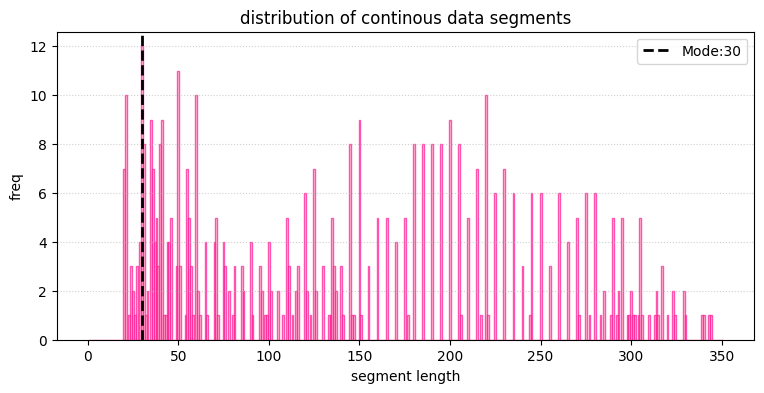

video of reconstruction
iteration done, moving to size 30
iteration 2, window size = 30
Training started for window size: 30 (train shape: (2815, 30))
Epoch 1/30
175/175 [==============================] - 3s 10ms/step - loss: 0.0017 - val_loss: 8.2707e-05
Epoch 2/30
175/175 [==============================] - 1s 8ms/step - loss: 6.0628e-05 - val_loss: 9.8093e-05
Epoch 3/30
175/175 [==============================] - 1s 8ms/step - loss: 6.0910e-05 - val_loss: 9.9803e-05
Epoch 4/30
175/175 [==============================] - 1s 8ms/step - loss: 6.0834e-05 - val_loss: 8.9044e-05
Epoch 5/30
175/175 [==============================] - 1s 8ms/step - loss: 6.0184e-05 - val_loss: 1.0240e-04
Epoch 6/30
175/175 [==============================] - 1s 7ms/step - loss: 5.9200e-05 - val_loss: 7.8864e-05
Epoch 7/30
175/175 [==============================] - 1s 7ms/step - loss: 6.1924e-05 - val_loss: 9.9951e-05
Epoch 8/30
175/175 [==============================] - 1s 8ms/step - loss: 6.0574e-05 - val_loss:

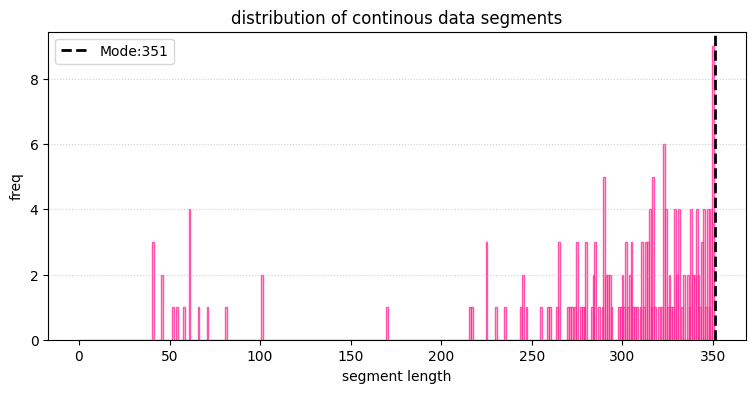

video of reconstruction
iteration done, moving to size 351
iteration 3, window size = 80
Training started for window size: 80 (train shape: (1075, 80))
Epoch 1/30
67/67 [==============================] - 2s 15ms/step - loss: 0.0032 - val_loss: 1.1737e-04
Epoch 2/30
67/67 [==============================] - 1s 12ms/step - loss: 9.5425e-05 - val_loss: 1.0154e-04
Epoch 3/30
67/67 [==============================] - 1s 12ms/step - loss: 8.4229e-05 - val_loss: 1.0131e-04
Epoch 4/30
67/67 [==============================] - 1s 12ms/step - loss: 9.7768e-05 - val_loss: 7.2980e-05
Epoch 5/30
67/67 [==============================] - 1s 11ms/step - loss: 8.2858e-05 - val_loss: 8.7285e-05
Epoch 6/30
67/67 [==============================] - 1s 12ms/step - loss: 7.4029e-05 - val_loss: 1.1762e-04
Epoch 7/30
67/67 [==============================] - 1s 12ms/step - loss: 7.6277e-05 - val_loss: 1.0168e-04
Epoch 8/30
67/67 [==============================] - 1s 13ms/step - loss: 7.0563e-05 - val_loss: 1.2130e

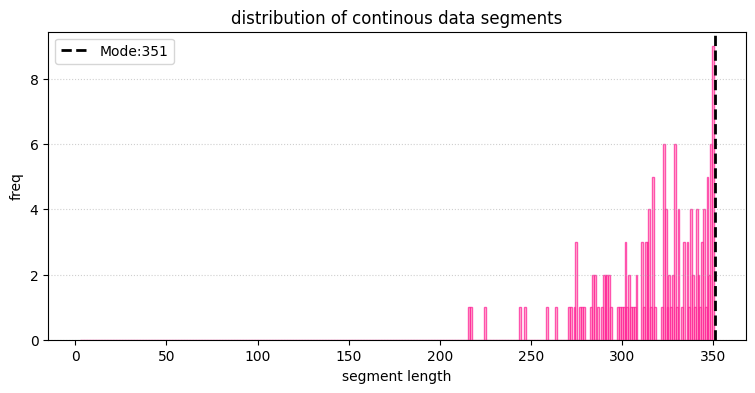

video of reconstruction
iteration done, moving to size 351
iteration 4, window size = 130
Training started for window size: 130 (train shape: (605, 130))
Epoch 1/30
37/37 [==============================] - 2s 28ms/step - loss: 0.0045 - val_loss: 3.7310e-04
Epoch 2/30
37/37 [==============================] - 1s 25ms/step - loss: 2.5973e-04 - val_loss: 1.1944e-04
Epoch 3/30
37/37 [==============================] - 1s 22ms/step - loss: 1.1290e-04 - val_loss: 1.1168e-04
Epoch 4/30
37/37 [==============================] - 1s 22ms/step - loss: 7.7499e-05 - val_loss: 9.5559e-05
Epoch 5/30
37/37 [==============================] - 1s 22ms/step - loss: 7.2791e-05 - val_loss: 8.0067e-05
Epoch 6/30
37/37 [==============================] - 1s 22ms/step - loss: 7.6180e-05 - val_loss: 7.6480e-05
Epoch 7/30
37/37 [==============================] - 1s 24ms/step - loss: 7.7556e-05 - val_loss: 1.1903e-04
Epoch 8/30
37/37 [==============================] - 1s 20ms/step - loss: 7.9261e-05 - val_loss: 1.163

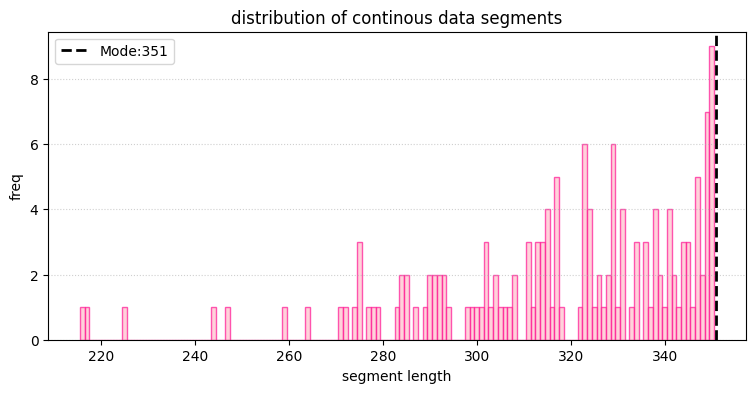

video of reconstruction
iteration done, moving to size 351
iteration 5, window size = 180
Training started for window size: 180 (train shape: (327, 180))
Epoch 1/30
20/20 [==============================] - 2s 34ms/step - loss: 0.0065 - val_loss: 8.8388e-04
Epoch 2/30
20/20 [==============================] - 1s 26ms/step - loss: 5.1194e-04 - val_loss: 1.3061e-04
Epoch 3/30
20/20 [==============================] - 1s 27ms/step - loss: 1.4875e-04 - val_loss: 1.0172e-04
Epoch 4/30
20/20 [==============================] - 1s 28ms/step - loss: 9.9140e-05 - val_loss: 5.7623e-05
Epoch 5/30
20/20 [==============================] - 1s 28ms/step - loss: 7.6699e-05 - val_loss: 6.4105e-05
Epoch 6/30
20/20 [==============================] - 1s 28ms/step - loss: 7.0463e-05 - val_loss: 6.4388e-05
Epoch 7/30
20/20 [==============================] - 1s 28ms/step - loss: 7.9179e-05 - val_loss: 6.4864e-05
Epoch 8/30
20/20 [==============================] - 1s 29ms/step - loss: 7.7636e-05 - val_loss: 7.507

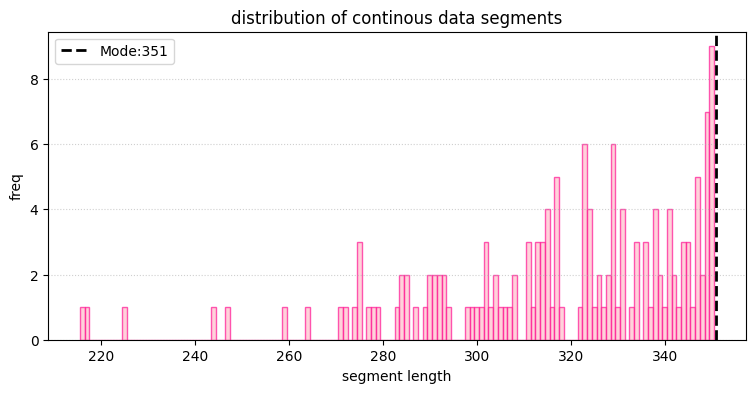

video of reconstruction
iteration done, moving to size 351
iteration 6, window size = 230
Training started for window size: 230 (train shape: (243, 230))
Epoch 1/30
15/15 [==============================] - 2s 44ms/step - loss: 0.0118 - val_loss: 0.0036
Epoch 2/30
15/15 [==============================] - 0s 33ms/step - loss: 0.0019 - val_loss: 8.2843e-04
Epoch 3/30
15/15 [==============================] - 0s 33ms/step - loss: 3.3682e-04 - val_loss: 3.0553e-04
Epoch 4/30
15/15 [==============================] - 1s 36ms/step - loss: 1.2901e-04 - val_loss: 1.0198e-04
Epoch 5/30
15/15 [==============================] - 1s 34ms/step - loss: 9.5961e-05 - val_loss: 8.8047e-05
Epoch 6/30
15/15 [==============================] - 0s 33ms/step - loss: 1.1184e-04 - val_loss: 9.8578e-05
Epoch 7/30
15/15 [==============================] - 0s 33ms/step - loss: 9.9098e-05 - val_loss: 8.2972e-05
Epoch 8/30
15/15 [==============================] - 0s 31ms/step - loss: 9.6284e-05 - val_loss: 8.5396e-05
Ep

In [43]:
# workflow using re-histogram method
#transect_df_norm_noDune=transect_df_norm.iloc[200:]
original_baseline_no_dune=transect_73_nodune.copy()
current_dataset=original_baseline_no_dune.copy()
original_data_mask=(~np.isnan(current_dataset)).astype(float)
active_mask=(~np.isnan(current_dataset)).astype(float)

historical_stages_zoo={}

total_iterations=6
current_window_size=10 # start size

pipeline_history={}
summary_stats=[]

for iteration in range(1,total_iterations+1):
    print(f"iteration {iteration}, window size = {current_window_size}")

    # index map of gaps
    current_windows_idx=find_windows_of_data(current_dataset,window_size=current_window_size,overlap_stride=int(current_window_size/2))
    # train model
    trained_model,history,test_ds=run_MAE(window_size=current_window_size,df=current_dataset,split_windows_idx=current_windows_idx,epochs=30)
    # reconstruct transect
    reconstructed_df=reconstruct_ds_with_MAE(model=trained_model,current_df=current_dataset,active_mask_df=active_mask,window_size=current_window_size,stride=5) # testing not keeping previous recons
    # store results
    stage_name=f"stage_{iteration}_size_{current_window_size}"
    historical_stages_zoo[stage_name]=reconstructed_df
    print("plotting error and loss")
    save_stage_loss_plot(history=history,window_size=current_window_size,stage_dir=savepath)

    #plot_reconstruction_matrix(current_df=current_dataset, active_mask_df=active_mask, filled_df=reconstructed_df, cmap='viridis', gap_color='deeppink')
    # update for loop
    current_dataset=reconstructed_df
    active_mask=(~np.isnan(current_dataset)).astype(float)
    # check next window size up
    if iteration<total_iterations:
        floor=current_window_size+10

        current_mode=reeval_and_hist(active_mask_df=active_mask,min_length=floor,target_val=1,plot_histogram=True,stage_label=f"post {stage_name}")

    if current_mode is not None:
        if current_mode<=current_window_size:
            current_window_size=current_window_size+15
        elif current_mode>=current_window_size+50: #keep from too big of a jump forward
            current_window_size=int(current_window_size+50) 
        else:
            current_window_size=int(current_mode)


    # save stats
    pipeline_history[current_window_size]={"model":trained_model,"history":history,"dataset_after_stage": reconstructed_df.copy()}
    #print("plotting static timesteps")
    #save_stage_comparison_plots(orig_full_df=transect_73, recon_no_dune_df=reconstructed_df,window_size=current_window_size,stage_dir=savepath)
    print("video of reconstruction")
    save_stage_video_animation(orig_full_df=transect_73,recon_no_dune_df=reconstructed_df,window_size=current_window_size,stage_dir=savepath,interval=500)
    

    print(f"iteration done, moving to size {current_mode}")

modelname="it1_R2L_MAE"
modelpath=os.path.join(savepath,f"{modelname}.keras")
trained_model.save(modelpath)
print(f"trained model saved to: {modelpath}")

#final stats
current_dataset=current_dataset
active_mask=(~np.isnan(current_dataset)).astype(float)

historical_stages_zoo["stage_final"]=current_dataset
save_stage_video_animation(orig_full_df=transect_73,recon_no_dune_df=current_dataset,window_size=current_window_size,stage_dir=savepath,interval=500)


In [44]:
df=pd.concat([transect_73.iloc[:200],reconstructed_df],ignore_index=True)
df_un_norm=unscale_dataframe(df,global_scaler)
df.to_csv("/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/R2L_buildingUp/iteration1_transects_norm.csv",index=False)
df_un_norm.to_csv("/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/R2L_buildingUp/iteration1_transects.csv",index=False)

ITERATION 2: One transect on either side

In [45]:
# QC training data (no values below zero)
train_ds[train_ds <0]=float('nan')
# normalize
#normalize training data

all_vals=train_ds.values.flatten()
all_vals=all_vals[~np.isnan(all_vals)]

min_elev=np.min(all_vals)
print("Minimum elev:", min_elev,"m")
max_elev=np.max(all_vals)
print("Max elev:", max_elev,"m")

#train_df_norm=(train_ds-min_elev)/(max_elev-min_elev)

Minimum elev: 0.449 m
Max elev: 10.141384615384617 m


In [46]:
#Grab transects closest to 7.3 for training
targets = ['transect_y6', 'transect_y8.3']
selected_transects = train_df_norm_nodune.query("transect_name in @targets")

In [47]:
print(selected_transects)

                                   0         1         2         3    \
transect_name original_index                                           
transect_y6   0                    NaN       NaN       NaN       NaN   
              1                    NaN       NaN       NaN       NaN   
              2                    NaN       NaN       NaN       NaN   
              3                    NaN       NaN       NaN       NaN   
              4               0.749632  0.749729       NaN  0.751821   
...                                ...       ...       ...       ...   
transect_y8.3 546                  NaN       NaN  0.634581  0.667017   
              547                  NaN       NaN  0.635219  0.668973   
              548                  NaN  0.631838  0.636913  0.670639   
              549                  NaN  0.630851  0.639933  0.672080   
              550                  NaN  0.631779  0.643190  0.673136   

                                   4         5         6       

total windows found: 5045
shortest window: 1
longest window: 431


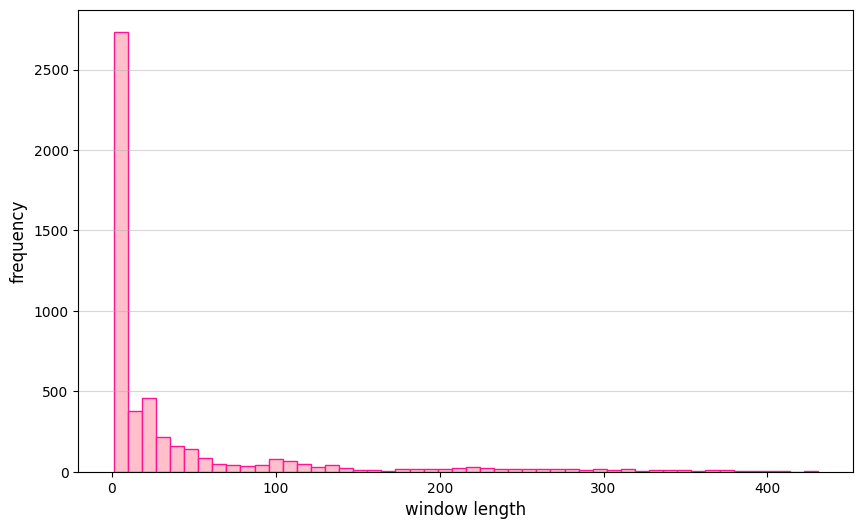

In [48]:
# find contnious windows of data for training ds
def what_window_sizes(df):
    lengths_per_col={}
    all_lengths=[]

    for col_name,col_data in df.items():
        arg=col_data.values
        masked=np.ma.masked_invalid(arg)
        clumps=np.ma.clump_unmasked(masked)

        lengths=[s.stop -s.start for s in clumps]
        lengths_per_col[col_name]=lengths
        all_lengths.extend(lengths)

    return lengths_per_col, all_lengths

lengths_by_col,total_lengths_list=what_window_sizes(selected_transects)

print(f"total windows found: {len(total_lengths_list)}")
print(f"shortest window: {np.min(total_lengths_list)}")
print(f"longest window: {np.max(total_lengths_list)}")

plt.figure(figsize=(10,6))

unique_lens=len(set(total_lengths_list))
bins=min(50,unique_lens) if unique_lens>0 else 10

plt.hist(total_lengths_list,bins=bins,color='pink',edgecolor='deeppink')
plt.xlabel('window length',fontsize=12)
plt.ylabel('frequency',fontsize=12)
plt.grid(axis="y",alpha=0.5)
plt.show()

    

In [49]:
from collections import Counter

filtered_lengths=[length for length in total_lengths_list if length>10]
length_counts=Counter(filtered_lengths)
top_five=length_counts.most_common(5)

for rank,(length,freq) in enumerate(top_five,1):
    print(f"{rank}. length: {length:<5} frequency: {freq:,}")


1. length: 21    frequency: 183
2. length: 22    frequency: 60
3. length: 20    frequency: 51
4. length: 12    frequency: 49
5. length: 11    frequency: 45


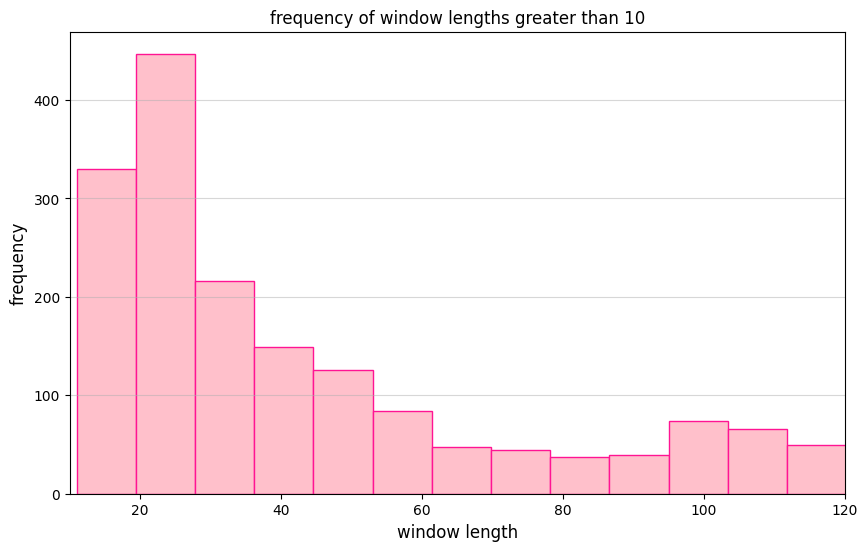

In [50]:
plt.figure(figsize=(10,6))

unique_lens=len(set(filtered_lengths))
bins=min(50,unique_lens) if unique_lens>0 else 10

plt.hist(filtered_lengths,bins=bins,color='pink',edgecolor='deeppink')
plt.xlabel('window length',fontsize=12)
plt.ylabel('frequency',fontsize=12)
plt.title("frequency of window lengths greater than 10")
plt.grid(axis="y",alpha=0.5)
plt.xlim(10,120)
plt.show()

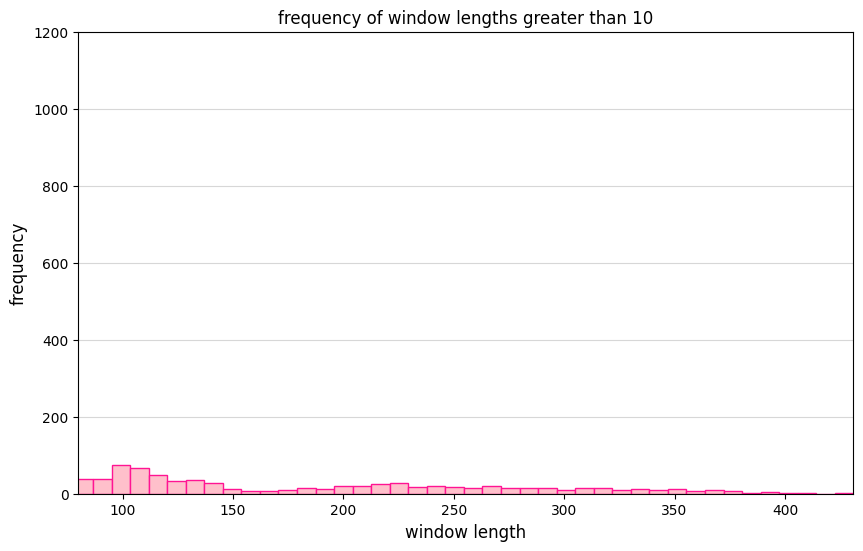

In [51]:
plt.figure(figsize=(10,6))

unique_lens=len(set(filtered_lengths))
bins=min(50,unique_lens) if unique_lens>0 else 10

plt.hist(filtered_lengths,bins=bins,color='pink',edgecolor='deeppink')
plt.xlabel('window length',fontsize=12)
plt.ylabel('frequency',fontsize=12)
plt.title("frequency of window lengths greater than 10")
plt.grid(axis="y",alpha=0.5)
plt.ylim(0,1200)
plt.xlim(80,431)
plt.show()

Define model and functions

In [52]:
def prep_training(train_source_df,split_windows_idx,batch_size=16):
    # windows of training/testing/vaidation data
    # run MAE training cycle per targeted window size
    timesteps=sorted(split_windows_idx.keys()) #chronological order
    n=len(timesteps)

    # train/val/test bounds
    train_end=int(n*0.7)
    val_end=int(n*0.85)

    train_time=timesteps[:train_end] #slice to grab train/test/val
    val_time=timesteps[train_end:val_end]
    test_time=timesteps[val_end:]

    def grab_windows(time_list): #loop through list of timesteps grab columnmand store as numpy vector
        X, info = [],[]
        for t in time_list:
            transect=train_source_df[t].values #grab from static training source
            
            for (start,stop) in split_windows_idx[t]: # windows of chosen size
                X.append(transect[start:stop])
                info.append({'timestep':t,'start':start,'stop':stop}) # store location to put back together
        return np.array(X, dtype="float32"), info
    
    X_train, info_train=grab_windows(train_time)
    X_val, info_val=grab_windows(val_time)
    X_test, info_test=grab_windows(test_time)

    # create ds function (mem efficient)
    def build_ds(X,info):
        starts=np.array([i['start'] for i in info]) # start points spatial
        tsteps=np.array([i['timestep'] for i in info]) # end points spatial
        ds=tf.data.Dataset.from_tensor_slices((X,starts,tsteps)) # arrays into TensorFlow tensor slice ds
        # mask over transect windows, process masks concureently, batches of 16, prep batch n+1 while working on current batch (efficiency)
        return (ds.map(masking_layer,num_parallel_calls=tf.data.AUTOTUNE).batch(batch_size,drop_remainder=True).prefetch(tf.data.AUTOTUNE))
    
    train_ds=build_ds(X_train,info_train)
    test_ds=build_ds(X_test,info_test)
    val_ds=build_ds(X_val,info_val)

    return train_ds, test_ds, val_ds

In [53]:
from tensorflow.keras.optimizers import Adam

In [54]:
def run_MAE(window_size,train_ds,val_ds, epochs=20):
    # inirialize model
    model=Denoise(window_size=window_size)
    #optimizer_tuned=Adam(learning_rate=1e-4)
    model.compile(optimizer='adam')

    #print(f"Training started for window size: {window_size} (train shape: {train_ds.shape})")
    history=model.fit(train_ds, validation_data=val_ds, epochs=epochs, verbose=1)
    return model, history

In [55]:
def reconstruct_ds_with_MAE(model, current_df, active_mask_df, window_size, stride=5):
    # slides MAE over the transects from left to right to impute where gaps exist
    # returns newly filled dataset
    x_matrix=tf.convert_to_tensor(current_df.values,dtype=tf.float32) # dataframe to tensorflow float 32
    transect_pts,tsteps=x_matrix.shape # length or cross-shore, timesteps

    mask_matrix=active_mask_df.values.astype(np.float32)
    #raw_groundtruth=baseline_raw_df.values

    reconstructed_all=[]

    for i in range(tsteps): # loop through every time step
        x_1dim=x_matrix[:,i].numpy() #current transect
        mask_1dim=mask_matrix[:,i] #gaps present in og or prev reconstrcution
        #raw_1dim=raw_groundtruth[:,i] #true og data

        full_recon=np.zeros_like(x_1dim) 
        counts=np.zeros_like(x_1dim)

        # slide window over full transect profile
        for start in range(0,transect_pts-window_size+1,stride):
            end=start+window_size

            #window_raw=raw_1dim[start:end] # window of raw data
            window_data=np.nan_to_num(x_1dim[start:end]) #slice of transect any nans to 0 current df
            window_mask=mask_1dim[start:end] #

            #model input shape
            combined_input=np.stack([window_data,window_mask],axis=-1).reshape(1,window_size,2) # transect slice with batch dim

            # check for too big of gap
            gap_too_big=is_gap_too_big(window_mask,window_size) 
            # check if window is full
            is_already_full = np.all(window_mask == 1.0)
            # check if the window has valid data on left and right edges
            has_bounded_edges = (window_mask[0] == 1.0) and (window_mask[-1] == 1.0)
            #double check there actually is a gap inside to fix (at least 1 point)
            has_gap_inside = np.any(window_mask == 0.0)

            # run MAE only if it's bounded on both sides
            if has_gap_inside and has_bounded_edges:
                #predict with MAE
                model_recon = model.predict(combined_input, verbose=0).flatten()
                # keep original data
                recon_window=np.where(window_mask==1.0,window_data,model_recon) # keep og data

                #preds for avg
                full_recon[start:end] = np.nansum([full_recon[start:end], recon_window], axis=0)
                counts[start:end] += 1
            
            elif is_already_full:
                #keep full window
                full_recon[start:end] = np.nansum([full_recon[start:end], window_data], axis=0)
                counts[start:end] += 1
        # trying to fix mismatch on gap edges
        raw_prediction=np.divide(full_recon,counts,out=np.full_like(full_recon,np.nan),where=counts>0)
        nan_indices=np.isnan(raw_prediction)
        raw_prediction[nan_indices]=x_1dim[nan_indices]

        final_transect=raw_prediction.copy()
        is_gap=(mask_1dim==0) # find gap
        gap_changes=np.diff(is_gap.astype(int))

        gap_starts=np.where(gap_changes==1)[0]+1
        gap_ends=np.where(gap_changes==-1)[0]

        # at the edge
        if is_gap[0]: gap_starts= np.insert(gap_starts,0,0)
        if is_gap[-1]: gap_ends=np.append(gap_ends,len(is_gap)-1)
        # smooth over transistion?
        blend_zone=min(4,int(window_size/4)) # transistion blending margin

        for g_start,g_end in zip(gap_starts,gap_ends):
            #left side blend
            if g_start>blend_zone:
                anchor_val=x_1dim[g_start -1] #known real value
                for b in range(blend_zone):
                    idx=g_start+b
                    if idx<= g_end:
                        # linear transition (Could do something better) from anchor to pred
                        alpha=(b+1)/(blend_zone +1)
                        final_transect[idx]=(1-alpha)*anchor_val+alpha*raw_prediction[idx]
            #right side
            if g_end< len(x_1dim)-blend_zone:
                anchor_val=x_1dim[g_end+1]
                for b in range(blend_zone):
                    idx=g_end-b
                    if idx>=g_start:
                        alpha=(b+1)/(blend_zone+1)
                        final_transect[idx]=(1-alpha)*anchor_val+alpha*raw_prediction[idx]


        # avg overlapping windows
        #final_transect=np.divide(full_recon,counts,out=np.full_like(full_recon,np.nan),where=counts>0)
        # keep anything if skipped
        #nan_indices=np.isnan(final_transect)
        #final_transect[nan_indices]=x_1dim[nan_indices]

        # overide to keep og data
        final_transect=np.where(mask_1dim==1.0,x_1dim,final_transect)

        reconstructed_all.append(final_transect)
    # return dataframe (points, timesteps)
    return pd.DataFrame(np.stack(reconstructed_all,axis=1),columns=current_df.columns)


In [56]:
def window_split(start,stop,size,overlap):
    return[(i,i+size) for i in range(start,stop-size+1,int(overlap))]

In [57]:
def find_windows_of_data(df,window_size,overlap_stride):
    # find the continous sections of data and extract window indices
    window_idx={}
    for timestep,transect in df.items():
        arg=transect.values
        masked=np.ma.masked_invalid(arg)
        clumps=np.ma.clump_unmasked(masked)
        window_idx[timestep]=[(s.start,s.stop)for s in clumps]

    split_windows_idx={}
    for timestep in window_idx:
        new_windows=[]
        for (start,stop) in window_idx[timestep]:
            length=stop-start
            if length>= window_size:
                new_windows.extend(window_split(start,stop,window_size,overlap_stride))
        split_windows_idx[timestep]=new_windows

    return split_windows_idx


In [58]:
from collections import Counter
def reeval_and_hist(active_mask_df,min_length,target_val=0,plot_histogram=True,stage_label=""):
    # functiin to histogram after reconstruction
    mask_matrix=active_mask_df.values
    spatial_pts,tsteps=mask_matrix.shape
    all_window_lengths=[]

    for col in range(tsteps):
        column=mask_matrix[:,col]
        is_target=(column==target_val) # find zeros
        # pad edges to get everything
        bound=np.hstack(([False],is_target,[False]))
        diffs=np.diff(bound.astype(int))

        starts=np.where(diffs==1)[0]
        ends=np.where(diffs==-1)[0]
        lengths=ends-starts

        all_window_lengths.extend(lengths)

    filtered_lengths=[l for l in all_window_lengths if l>=min_length]

    freq_map=Counter(filtered_lengths)
    mode_size=freq_map.most_common(1)[0][0]

    print(f"mode: {mode_size}")
    print(f"max length: {max(filtered_lengths)}")
    print(f"min length: {min(filtered_lengths)}")

    if plot_histogram:
        plt.figure(figsize=(9,4))
        plt.hist(filtered_lengths,bins=np.arange(min(all_window_lengths)-0.5, max(all_window_lengths)+0.5,1),color='pink',edgecolor='deeppink',alpha=0.7)
        plt.axvline(mode_size,color='black',linestyle='--',linewidth=2,label=f'Mode:{mode_size}')
        plt.title(f'distribution of continous data segments')
        plt.xlabel('segment length')
        plt.ylabel('freq')
        plt.legend()
        plt.grid(axis='y',linestyle=':',alpha=0.6)
        plt.show()

        return mode_size


In [59]:
def save_stage_video_animation(orig_full_df, recon_no_dune_df, window_size, stage_dir="stage_outputs", interval=500):
    """
    Creates and saves a dynamic video tracking profile repairs over time,
    maintaining the unedited dune profile on the left.
    """
    os.makedirs(stage_dir, exist_ok=True)
   
    DUNE_OFFSET = 200
    orig_full_data = orig_full_df.values
    recon_no_dune_data = recon_no_dune_df.values
   
    n_points, n_timesteps = orig_full_data.shape
    x_coords = np.arange(n_points)

    fig, ax = plt.subplots(figsize=(12, 5))
   
    # Set standard layout constraints based on full dataset limits
    ax.set_xlim(0, n_points)
    ax.set_ylim(np.nanmin(orig_full_data) - 0.1, np.nanmax(orig_full_data) + 0.1)
    ax.set_xlabel("Full Cross-shore index")
    ax.set_ylabel("Normalized Elevation")
   
    # Initialize baseline handles
    line_recon, = ax.plot([], [], color='deeppink', linewidth=2, label=f'MAE-{window_size} Active Pass')
    line_orig, = ax.plot([], [], color='blue', alpha=0.6, label='Original Survey (with Dune)')
    #line_recon, = ax.plot([], [], color='deeppink', linewidth=2, label=f'MAE-{window_size} Active Pass')
   
    # Draw static divider indicator
    ax.axvline(x=DUNE_OFFSET, color='black', linestyle=':', alpha=0.4)
    ax.legend(loc='lower left')

    # gaps as highlights
    gap_spans=[]
    gap_patch=plt.Rectangle((0,0),1,1,fc="gray", alpha=0.3,label='gaps')
    ax.legend(handles=[line_orig,line_recon,gap_patch],loc='lower left')

    def update(frame):
        nonlocal gap_spans
        for span in gap_spans:
            span.remove()
        gap_spans.clear()
        y_orig = orig_full_data[:, frame]
       
        # Stitch the original dune to the model's currently filled lower beach
        y_recon_full = y_orig.copy()
        y_recon_full[DUNE_OFFSET:] = recon_no_dune_data[:, frame]

        is_gap=np.isnan(y_orig)
        is_gap[:DUNE_OFFSET]=False #ignore gaps in dune

        if np.any(is_gap):
            diff=np.diff(is_gap.astype(int))
            gap_starts=np.where(diff==1)[0]+1
            gap_ends=np.where(diff==-1)[0]+1

            if is_gap[0]:
                gap_starts=np.insert(gap_starts,0,0)
            if is_gap[-1]:
                gap_ends=np.append(gap_ends,n_points-1)

            for start,end in zip(gap_starts, gap_ends):
                span=ax.axvspan(start,end,color='gray',alpha=0.25,zorder=0)
                gap_spans.append(span)

       
        line_recon.set_data(x_coords, y_recon_full)
        line_orig.set_data(x_coords, y_orig)
        #line_recon.set_data(x_coords, y_recon_full)
       
        ax.set_title(f"Full Reconstruction | Stage: MAE-{window_size} | Timestep: {frame}")
        return [line_orig, line_recon] + gap_spans

    anim = FuncAnimation(fig, update, frames=n_timesteps, interval=interval, blit=True)
   
    video_path = os.path.join(stage_dir, f"full_profile_stage_MAE{window_size}.gif")
    anim.save(video_path, writer="pillow")
    plt.close()

Train and run MAE

In [60]:
def unscale_dataframe(df,fitted_scalar):
    matrix=df.values.copy()
    flat_vals=matrix.reshape(-1,1)
    non_nan_mask=~np.isnan(flat_vals)
    # reverse scaling
    flat_vals[non_nan_mask]=fitted_scalar.inverse_transform(flat_vals[non_nan_mask].reshape(-1,1)).flatten()
    unscaled_df=pd.DataFrame(flat_vals.reshape(df.shape),columns=df.columns,index=df.index)
    return unscaled_df

Epoch 1/30
1545/1545 [==============================] - 27s 17ms/step - loss: 6.6454e-04 - val_loss: 2.9269e-04
Epoch 2/30
1545/1545 [==============================] - 27s 18ms/step - loss: 1.6048e-04 - val_loss: 1.0178e-05
Epoch 3/30
1545/1545 [==============================] - 27s 18ms/step - loss: 4.4106e-05 - val_loss: 1.7964e-05
Epoch 4/30
1545/1545 [==============================] - 27s 17ms/step - loss: 5.5790e-05 - val_loss: 1.2631e-05
Epoch 5/30
1545/1545 [==============================] - 25s 16ms/step - loss: 4.5993e-05 - val_loss: 3.1679e-05
Epoch 6/30
1545/1545 [==============================] - 25s 16ms/step - loss: 3.1458e-05 - val_loss: 3.3578e-05
Epoch 7/30
1545/1545 [==============================] - 25s 16ms/step - loss: 3.1050e-05 - val_loss: 1.2455e-05
Epoch 8/30
1545/1545 [==============================] - 24s 15ms/step - loss: 3.2425e-05 - val_loss: 1.6649e-05
Epoch 9/30
1545/1545 [==============================] - 24s 15ms/step - loss: 4.1465e-05 - val_loss: 2.8

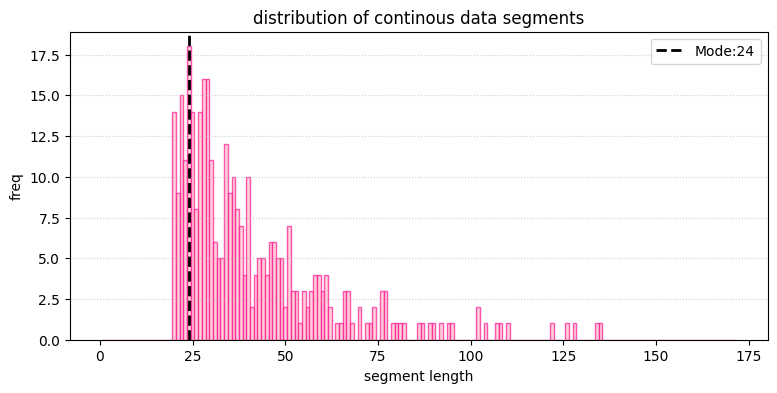

iteration done, moving to size 24
Epoch 1/30
558/558 [==============================] - 10s 16ms/step - loss: 9.6212e-04 - val_loss: 1.8614e-04
Epoch 2/30
558/558 [==============================] - 9s 16ms/step - loss: 2.1319e-04 - val_loss: 1.5761e-04
Epoch 3/30
558/558 [==============================] - 9s 16ms/step - loss: 2.1451e-04 - val_loss: 1.7748e-04
Epoch 4/30
558/558 [==============================] - 8s 15ms/step - loss: 2.1065e-04 - val_loss: 1.3599e-04
Epoch 5/30
558/558 [==============================] - 9s 16ms/step - loss: 1.8445e-04 - val_loss: 1.5433e-04
Epoch 6/30
558/558 [==============================] - 9s 16ms/step - loss: 1.1930e-04 - val_loss: 4.1841e-05
Epoch 7/30
558/558 [==============================] - 9s 16ms/step - loss: 5.8985e-05 - val_loss: 2.4296e-05
Epoch 8/30
558/558 [==============================] - 9s 16ms/step - loss: 4.1601e-05 - val_loss: 5.6039e-05
Epoch 9/30
558/558 [==============================] - 9s 16ms/step - loss: 5.2204e-05 - val_l

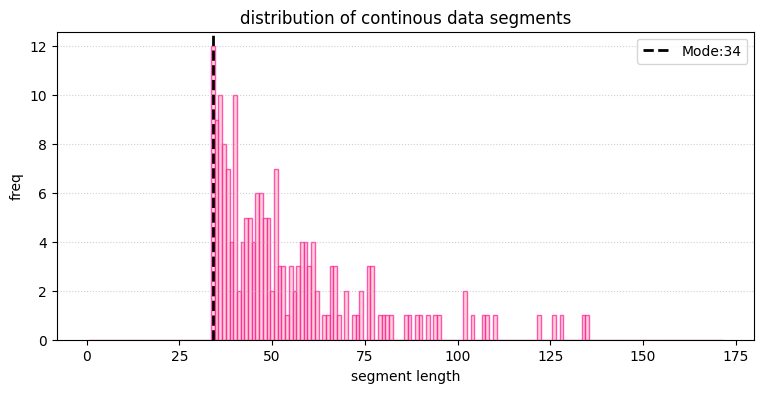

iteration done, moving to size 34
Epoch 1/30
363/363 [==============================] - 3s 6ms/step - loss: 9.5807e-04 - val_loss: 2.2773e-04
Epoch 2/30
363/363 [==============================] - 2s 5ms/step - loss: 2.0930e-04 - val_loss: 2.5487e-04
Epoch 3/30
363/363 [==============================] - 2s 6ms/step - loss: 2.1426e-04 - val_loss: 2.2843e-04
Epoch 4/30
363/363 [==============================] - 2s 6ms/step - loss: 2.2090e-04 - val_loss: 2.3021e-04
Epoch 5/30
363/363 [==============================] - 2s 5ms/step - loss: 1.9775e-04 - val_loss: 2.0772e-04
Epoch 6/30
363/363 [==============================] - 2s 5ms/step - loss: 1.3827e-04 - val_loss: 7.2617e-05
Epoch 7/30
363/363 [==============================] - 2s 5ms/step - loss: 6.3321e-05 - val_loss: 3.3308e-05
Epoch 8/30
363/363 [==============================] - 2s 5ms/step - loss: 5.0554e-05 - val_loss: 3.2686e-05
Epoch 9/30
363/363 [==============================] - 2s 5ms/step - loss: 4.5285e-05 - val_loss: 2.576

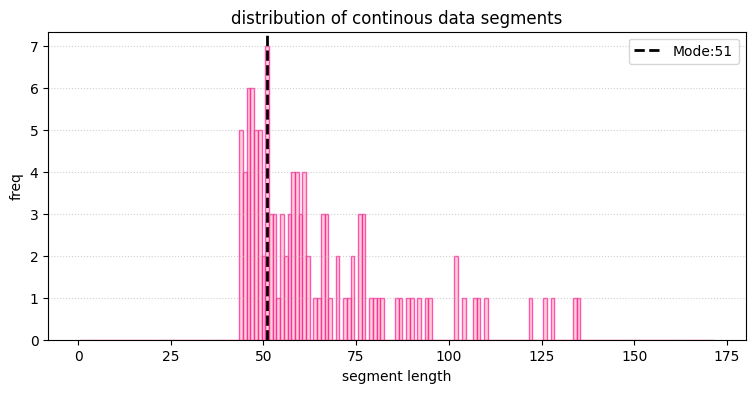

iteration done, moving to size 51
Epoch 1/30
217/217 [==============================] - 3s 10ms/step - loss: 0.0015 - val_loss: 2.3678e-04
Epoch 2/30
217/217 [==============================] - 2s 9ms/step - loss: 2.1337e-04 - val_loss: 2.6342e-04
Epoch 3/30
217/217 [==============================] - 2s 9ms/step - loss: 1.9815e-04 - val_loss: 2.2779e-04
Epoch 4/30
217/217 [==============================] - 2s 9ms/step - loss: 2.0209e-04 - val_loss: 2.7031e-04
Epoch 5/30
217/217 [==============================] - 2s 8ms/step - loss: 2.0221e-04 - val_loss: 2.6119e-04
Epoch 6/30
217/217 [==============================] - 2s 8ms/step - loss: 2.0152e-04 - val_loss: 2.8917e-04
Epoch 7/30
217/217 [==============================] - 2s 8ms/step - loss: 1.9537e-04 - val_loss: 2.5905e-04
Epoch 8/30
217/217 [==============================] - 2s 8ms/step - loss: 1.9226e-04 - val_loss: 2.0688e-04
Epoch 9/30
217/217 [==============================] - 2s 8ms/step - loss: 1.6446e-04 - val_loss: 1.7511e-

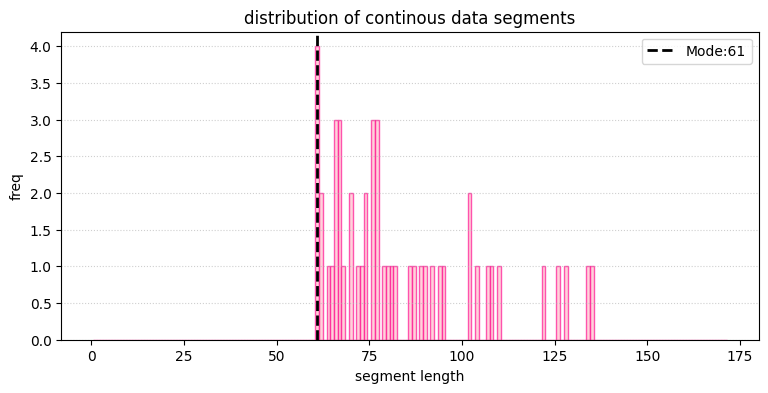

iteration done, moving to size 61
Epoch 1/30
167/167 [==============================] - 3s 10ms/step - loss: 0.0020 - val_loss: 1.8088e-04
Epoch 2/30
167/167 [==============================] - 2s 9ms/step - loss: 1.9312e-04 - val_loss: 2.0329e-04
Epoch 3/30
167/167 [==============================] - 2s 10ms/step - loss: 1.9384e-04 - val_loss: 2.3110e-04
Epoch 4/30
167/167 [==============================] - 2s 11ms/step - loss: 1.8697e-04 - val_loss: 2.3403e-04
Epoch 5/30
167/167 [==============================] - 2s 9ms/step - loss: 1.9047e-04 - val_loss: 2.4645e-04
Epoch 6/30
167/167 [==============================] - 1s 9ms/step - loss: 1.8567e-04 - val_loss: 2.5224e-04
Epoch 7/30
167/167 [==============================] - 1s 9ms/step - loss: 1.8389e-04 - val_loss: 2.0909e-04
Epoch 8/30
167/167 [==============================] - 1s 9ms/step - loss: 1.7532e-04 - val_loss: 1.8083e-04
Epoch 9/30
167/167 [==============================] - 1s 8ms/step - loss: 1.5962e-04 - val_loss: 1.3606

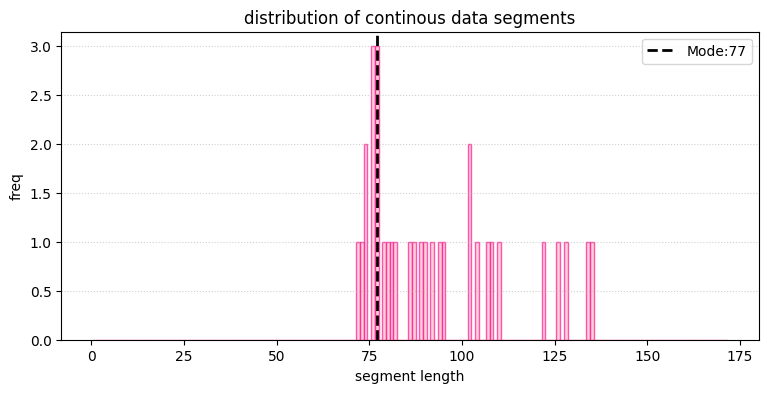

iteration done, moving to size 77
Epoch 1/30
119/119 [==============================] - 2s 11ms/step - loss: 0.0026 - val_loss: 1.6990e-04
Epoch 2/30
119/119 [==============================] - 1s 10ms/step - loss: 2.0656e-04 - val_loss: 2.5003e-04
Epoch 3/30
119/119 [==============================] - 1s 9ms/step - loss: 1.9904e-04 - val_loss: 1.8721e-04
Epoch 4/30
119/119 [==============================] - 1s 10ms/step - loss: 1.9219e-04 - val_loss: 2.2476e-04
Epoch 5/30
119/119 [==============================] - 1s 10ms/step - loss: 1.9187e-04 - val_loss: 1.7323e-04
Epoch 6/30
119/119 [==============================] - 1s 11ms/step - loss: 1.9247e-04 - val_loss: 2.0162e-04
Epoch 7/30
119/119 [==============================] - 1s 10ms/step - loss: 1.8971e-04 - val_loss: 2.4785e-04
Epoch 8/30
119/119 [==============================] - 1s 10ms/step - loss: 1.8477e-04 - val_loss: 2.1339e-04
Epoch 9/30
119/119 [==============================] - 1s 9ms/step - loss: 1.8354e-04 - val_loss: 1.

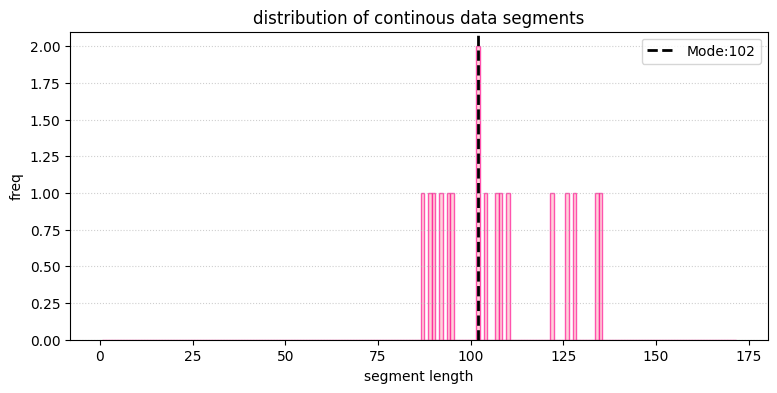

iteration done, moving to size 102
Epoch 1/30
75/75 [==============================] - 2s 14ms/step - loss: 0.0033 - val_loss: 2.8195e-04
Epoch 2/30
75/75 [==============================] - 1s 12ms/step - loss: 1.9962e-04 - val_loss: 2.8007e-04
Epoch 3/30
75/75 [==============================] - 1s 11ms/step - loss: 1.8047e-04 - val_loss: 3.1156e-04
Epoch 4/30
75/75 [==============================] - 1s 11ms/step - loss: 1.8276e-04 - val_loss: 2.3780e-04
Epoch 5/30
75/75 [==============================] - 1s 14ms/step - loss: 1.9679e-04 - val_loss: 2.9654e-04
Epoch 6/30
75/75 [==============================] - 1s 11ms/step - loss: 1.9766e-04 - val_loss: 2.4827e-04
Epoch 7/30
75/75 [==============================] - 1s 11ms/step - loss: 1.9029e-04 - val_loss: 2.1399e-04
Epoch 8/30
75/75 [==============================] - 1s 11ms/step - loss: 1.9494e-04 - val_loss: 2.7803e-04
Epoch 9/30
75/75 [==============================] - 1s 12ms/step - loss: 2.0393e-04 - val_loss: 1.9531e-04
Epoch 

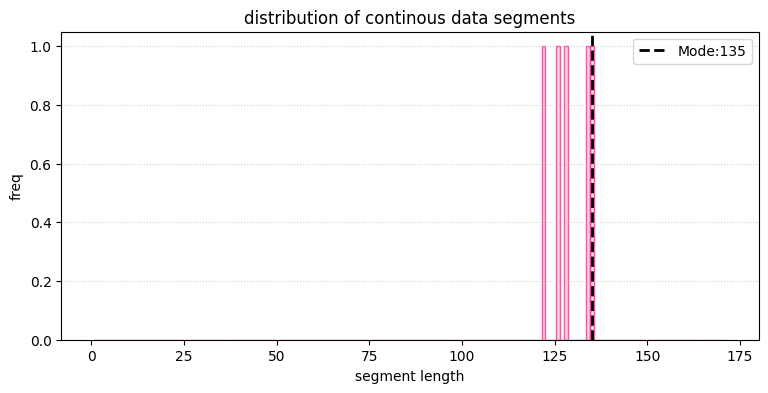

iteration done, moving to size 135
Epoch 1/30
45/45 [==============================] - 2s 26ms/step - loss: 0.0047 - val_loss: 4.4491e-04
Epoch 2/30
45/45 [==============================] - 1s 22ms/step - loss: 2.4123e-04 - val_loss: 2.4504e-04
Epoch 3/30
45/45 [==============================] - 1s 21ms/step - loss: 1.7781e-04 - val_loss: 2.4657e-04
Epoch 4/30
45/45 [==============================] - 1s 20ms/step - loss: 1.6871e-04 - val_loss: 2.2332e-04
Epoch 5/30
45/45 [==============================] - 1s 21ms/step - loss: 1.7174e-04 - val_loss: 1.8458e-04
Epoch 6/30
45/45 [==============================] - 1s 23ms/step - loss: 1.6940e-04 - val_loss: 2.4916e-04
Epoch 7/30
45/45 [==============================] - 1s 21ms/step - loss: 1.6985e-04 - val_loss: 2.0100e-04
Epoch 8/30
45/45 [==============================] - 1s 22ms/step - loss: 1.7595e-04 - val_loss: 2.3014e-04
Epoch 9/30
45/45 [==============================] - 1s 20ms/step - loss: 1.7348e-04 - val_loss: 3.2927e-04
Epoch 

In [61]:
# updated method with training data from alongshore transects
savepath=r'/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/Figures/R2L_results_prelim/building_up/iteration2'
# grabbing transect for predictions
#transect_df_norm_noDune=transect_df_norm.iloc[200:]
original_baseline_no_dune=transect_73_nodune.copy()
current_dataset=original_baseline_no_dune.copy()
original_data_mask=(~np.isnan(current_dataset)).astype(float)
active_mask=(~np.isnan(current_dataset)).astype(float)
training_ds=selected_transects.copy() # this is no dune
# starting vars
historical_stages_zoo={}
total_iterations=8
current_window_size=10 # start size
pipeline_history={}
summary_stats=[]

for iteration in range (1,total_iterations+1):
    # map of gaps in transect for training (where is there data)
    current_windows_idx=find_windows_of_data(training_ds,window_size=current_window_size,overlap_stride=int(current_window_size/2))
    # prep alongshore transect windows of given size (add in part where you grab inbtween windows) (training data)
    tf_train,tf_val,tf_test=prep_training(train_source_df=training_ds,split_windows_idx=current_windows_idx,batch_size=16)
    # run model
    trained_model,history=run_MAE(window_size=current_window_size,train_ds=tf_train,val_ds=tf_val,epochs=30)
    # reconstruct transect
    reconstructed_df=reconstruct_ds_with_MAE(model=trained_model,current_df=current_dataset,active_mask_df=active_mask,window_size=current_window_size,stride=5)
    # store results
    eval_windows_idx=find_windows_of_data(current_dataset,window_size=current_window_size, overlap_stride=int(current_window_size/2))# need for metrics (where are gaps)
    stage_name=f"stage_{iteration}_size_{current_window_size}"
    historical_stages_zoo[stage_name]=reconstructed_df
    print("plotting error and loss")
    save_stage_loss_plot(history=history,window_size=current_window_size,stage_dir=savepath)
    # update for loop
    current_dataset=reconstructed_df
    active_mask=(~np.isnan(current_dataset)).astype(float)

    # unscale data for plotting
    #recon_phys_df=unscale_dataframe(reconstructed_df,global_scaler)
    #orig_phys_df=transect_df_raw.copy()
    #recon_phys_df[original_baseline_no_dune.isna()]=np.nan
    
    # save stats
    pipeline_history[current_window_size]={"model":trained_model,"history":history,"dataset_after_stage": reconstructed_df.copy()}
    print("plotting static timesteps")
    save_stage_comparison_plots(orig_full_df=transect_73, recon_no_dune_df=reconstructed_df,window_size=current_window_size,stage_dir=savepath)
    print("video of reconstruction")
    save_stage_video_animation(orig_full_df=transect_73, recon_no_dune_df=reconstructed_df,window_size=current_window_size,stage_dir=savepath,interval=500)
    #save_stage_gaps_video_animation(orig_full_df=train_df_norm,recon_no_dune_df=reconstructed_df,window_size=current_window_size,stage_dir=savepath,interval=500)

    # check next window size up
    if iteration<total_iterations:
        floor=current_window_size+10

        current_mode=reeval_and_hist(active_mask_df=active_mask,min_length=floor,target_val=0,plot_histogram=True,stage_label=f"post {stage_name}")

    if current_mode is not None:
        if current_mode<=current_window_size:
            current_window_size=current_window_size+15
        else:
            current_window_size=int(current_mode)

    print(f"iteration done, moving to size {current_mode}")
    
modelname="it2_R2L_MAE"
modelpath=os.path.join(savepath,f"{modelname}.keras")
trained_model.save(modelpath)
print(f"trained model saved to: {modelpath}")

In [62]:
df=pd.concat([transect_73.iloc[:200],reconstructed_df],ignore_index=True)
df_un_norm=unscale_dataframe(df,global_scaler)
df.to_csv("/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/R2L_buildingUp/iteration2_transects_norm.csv",index=False)
df_un_norm.to_csv("/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/R2L_buildingUp/iteration2_transects.csv",index=False)

ITERATION 3: 5 Transects on either side of transect 7.3


In [63]:
#Grab transects closest to 7.3 for training
targets = ['transect_y6', 'transect_y8.3','transect_y4','transect_y2','transect_y0','transect_y-2','transect_y10.3','transect_y12.3','transect_y14.3','transect_y16.3']
selected_transects = train_df_norm_nodune.query("transect_name in @targets")
print(selected_transects)

                               0    1    2    3    4    5    6    7    8    \
transect_name  original_index                                                
transect_y-2   0               NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
               1               NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
               2               NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
               3               NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
               4               NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
...                            ...  ...  ...  ...  ...  ...  ...  ...  ...   
transect_y16.3 546             NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
               547             NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
               548             NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
               549             NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
               550             NaN  NaN  NaN  NaN  NaN  NaN  NaN

total windows found: 24034
shortest window: 1
longest window: 431


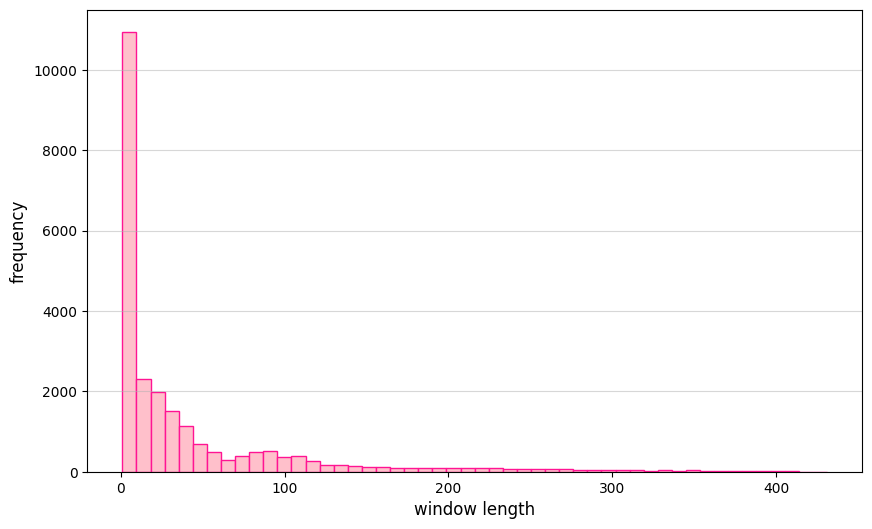

1. length: 11    frequency: 437
2. length: 21    frequency: 372
3. length: 22    frequency: 326
4. length: 30    frequency: 288
5. length: 17    frequency: 277


In [64]:
lengths_by_col,total_lengths_list=what_window_sizes(selected_transects)

print(f"total windows found: {len(total_lengths_list)}")
print(f"shortest window: {np.min(total_lengths_list)}")
print(f"longest window: {np.max(total_lengths_list)}")

plt.figure(figsize=(10,6))

unique_lens=len(set(total_lengths_list))
bins=min(50,unique_lens) if unique_lens>0 else 10

plt.hist(total_lengths_list,bins=bins,color='pink',edgecolor='deeppink')
plt.xlabel('window length',fontsize=12)
plt.ylabel('frequency',fontsize=12)
plt.grid(axis="y",alpha=0.5)
plt.show()

filtered_lengths=[length for length in total_lengths_list if length>10]
length_counts=Counter(filtered_lengths)
top_five=length_counts.most_common(5)

for rank,(length,freq) in enumerate(top_five,1):
    print(f"{rank}. length: {length:<5} frequency: {freq:,}")


Epoch 1/30
7464/7464 [==============================] - 104s 14ms/step - loss: 2.7210e-04 - val_loss: 8.9520e-06
Epoch 2/30
7464/7464 [==============================] - 107s 14ms/step - loss: 4.0795e-05 - val_loss: 1.9262e-05
Epoch 3/30
7464/7464 [==============================] - 105s 14ms/step - loss: 3.0301e-05 - val_loss: 8.4778e-06
Epoch 4/30
7464/7464 [==============================] - 110s 15ms/step - loss: 3.4475e-05 - val_loss: 2.9132e-06
Epoch 5/30
7464/7464 [==============================] - 108s 14ms/step - loss: 2.7500e-05 - val_loss: 6.8716e-06
Epoch 6/30
7464/7464 [==============================] - 111s 15ms/step - loss: 2.4321e-05 - val_loss: 9.5431e-06
Epoch 7/30
7464/7464 [==============================] - 115s 15ms/step - loss: 2.1617e-05 - val_loss: 8.3873e-06
Epoch 8/30
7464/7464 [==============================] - 113s 15ms/step - loss: 2.8949e-05 - val_loss: 1.9258e-06
Epoch 9/30
7464/7464 [==============================] - 109s 15ms/step - loss: 2.5639e-05 - val_

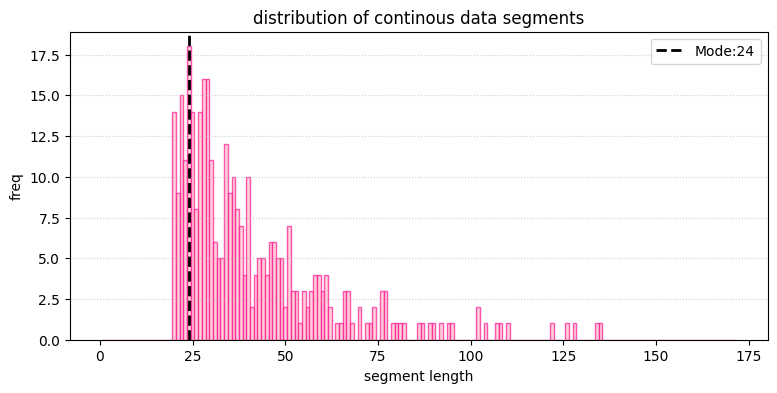

iteration done, moving to size 24
Epoch 1/30
2640/2640 [==============================] - 47s 17ms/step - loss: 4.1454e-04 - val_loss: 9.8146e-05
Epoch 2/30
2640/2640 [==============================] - 46s 17ms/step - loss: 6.0281e-05 - val_loss: 3.2605e-05
Epoch 3/30
2640/2640 [==============================] - 46s 18ms/step - loss: 4.3225e-05 - val_loss: 2.4609e-05
Epoch 4/30
2640/2640 [==============================] - 46s 17ms/step - loss: 4.0613e-05 - val_loss: 1.4764e-05
Epoch 5/30
2640/2640 [==============================] - 45s 17ms/step - loss: 2.7601e-05 - val_loss: 9.4680e-06
Epoch 6/30
2640/2640 [==============================] - 46s 17ms/step - loss: 2.4859e-05 - val_loss: 5.5158e-05
Epoch 7/30
2640/2640 [==============================] - 44s 17ms/step - loss: 3.3750e-05 - val_loss: 2.1040e-05
Epoch 8/30
2640/2640 [==============================] - 45s 17ms/step - loss: 2.5451e-05 - val_loss: 6.6511e-06
Epoch 9/30
2640/2640 [==============================] - 42s 16ms/step 

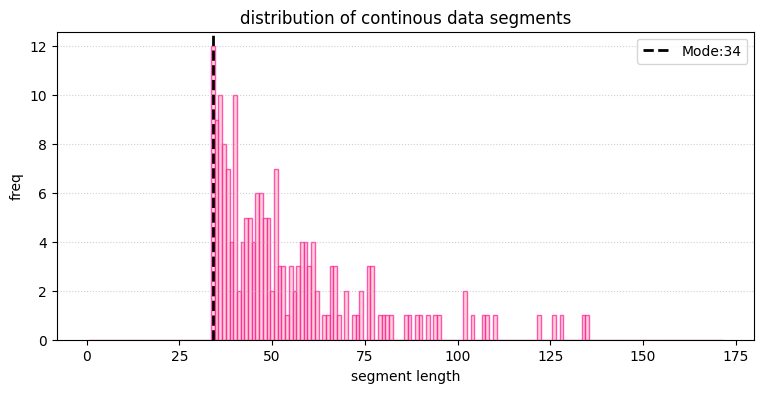

iteration done, moving to size 34
Epoch 1/30
1674/1674 [==============================] - 10s 5ms/step - loss: 4.2290e-04 - val_loss: 3.0712e-05
Epoch 2/30
1674/1674 [==============================] - 7s 4ms/step - loss: 5.5365e-05 - val_loss: 3.9226e-05
Epoch 3/30
1674/1674 [==============================] - 7s 4ms/step - loss: 4.4587e-05 - val_loss: 5.9356e-05
Epoch 4/30
1674/1674 [==============================] - 7s 4ms/step - loss: 3.8690e-05 - val_loss: 2.3388e-05
Epoch 5/30
1674/1674 [==============================] - 7s 4ms/step - loss: 3.7892e-05 - val_loss: 3.0135e-05
Epoch 6/30
1674/1674 [==============================] - 8s 4ms/step - loss: 4.1928e-05 - val_loss: 1.8158e-05
Epoch 7/30
1674/1674 [==============================] - 8s 5ms/step - loss: 2.8804e-05 - val_loss: 8.9421e-06
Epoch 8/30
1674/1674 [==============================] - 7s 4ms/step - loss: 2.4088e-05 - val_loss: 8.9536e-06
Epoch 9/30
1674/1674 [==============================] - 7s 4ms/step - loss: 2.8049e-0

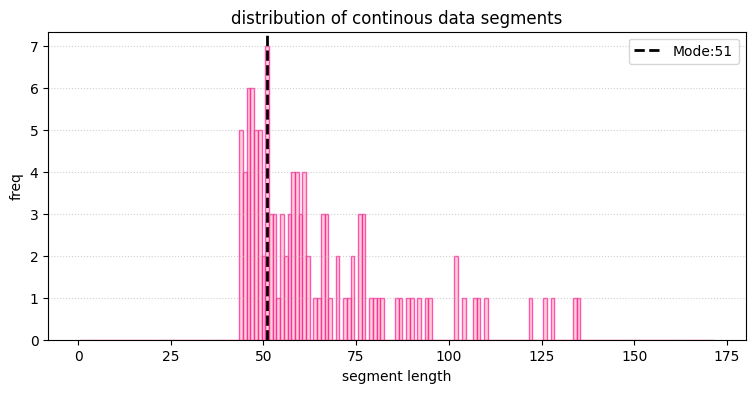

iteration done, moving to size 51
Epoch 1/30
963/963 [==============================] - 8s 7ms/step - loss: 4.6487e-04 - val_loss: 1.7312e-04
Epoch 2/30
963/963 [==============================] - 6s 6ms/step - loss: 1.4383e-04 - val_loss: 3.9529e-05
Epoch 3/30
963/963 [==============================] - 6s 7ms/step - loss: 6.6775e-05 - val_loss: 3.1268e-05
Epoch 4/30
963/963 [==============================] - 6s 6ms/step - loss: 4.8779e-05 - val_loss: 1.8279e-05
Epoch 5/30
963/963 [==============================] - 7s 7ms/step - loss: 3.4638e-05 - val_loss: 2.3296e-05
Epoch 6/30
963/963 [==============================] - 6s 7ms/step - loss: 4.0659e-05 - val_loss: 3.9064e-05
Epoch 7/30
963/963 [==============================] - 6s 6ms/step - loss: 3.9637e-05 - val_loss: 4.8483e-05
Epoch 8/30
963/963 [==============================] - 6s 6ms/step - loss: 3.4297e-05 - val_loss: 1.6492e-05
Epoch 9/30
963/963 [==============================] - 7s 7ms/step - loss: 3.7353e-05 - val_loss: 1.113

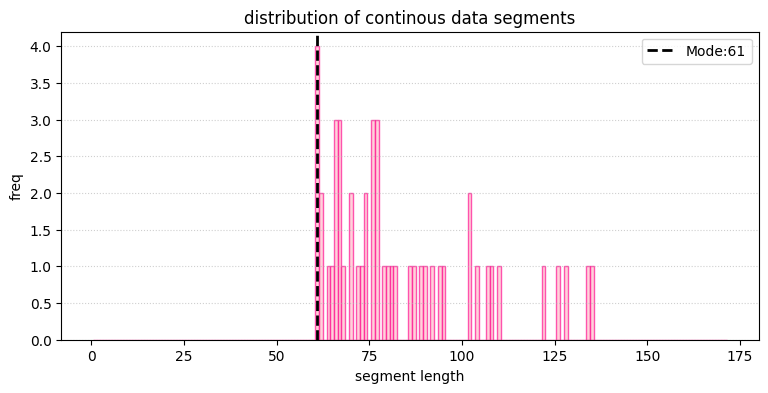

iteration done, moving to size 61
Epoch 1/30
724/724 [==============================] - 9s 12ms/step - loss: 6.0068e-04 - val_loss: 3.2832e-04
Epoch 2/30
724/724 [==============================] - 8s 11ms/step - loss: 2.0934e-04 - val_loss: 2.3103e-04
Epoch 3/30
724/724 [==============================] - 8s 11ms/step - loss: 1.7214e-04 - val_loss: 4.8067e-05
Epoch 4/30
724/724 [==============================] - 9s 12ms/step - loss: 7.2125e-05 - val_loss: 4.3991e-05
Epoch 5/30
724/724 [==============================] - 9s 12ms/step - loss: 4.0422e-05 - val_loss: 4.6936e-05
Epoch 6/30
724/724 [==============================] - 9s 12ms/step - loss: 4.6412e-05 - val_loss: 3.2926e-05
Epoch 7/30
724/724 [==============================] - 8s 12ms/step - loss: 3.7141e-05 - val_loss: 6.7291e-05
Epoch 8/30
724/724 [==============================] - 9s 12ms/step - loss: 3.7683e-05 - val_loss: 4.9079e-05
Epoch 9/30
724/724 [==============================] - 8s 10ms/step - loss: 3.3575e-05 - val_lo

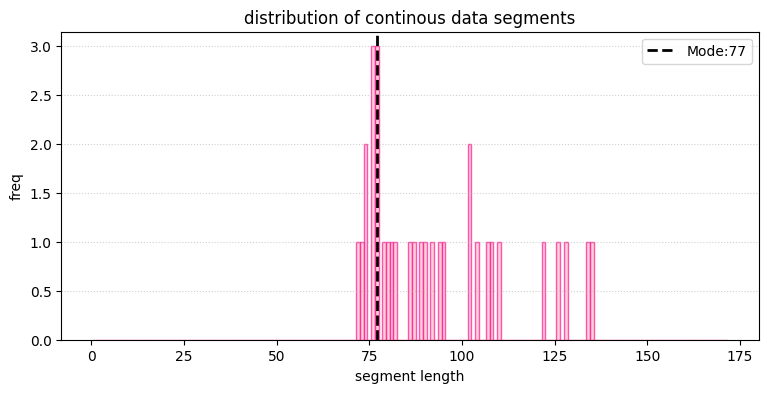

iteration done, moving to size 77
Epoch 1/30
503/503 [==============================] - 6s 10ms/step - loss: 7.1838e-04 - val_loss: 2.0002e-04
Epoch 2/30
503/503 [==============================] - 5s 10ms/step - loss: 1.8805e-04 - val_loss: 2.1196e-04
Epoch 3/30
503/503 [==============================] - 4s 9ms/step - loss: 1.8901e-04 - val_loss: 2.2723e-04
Epoch 4/30
503/503 [==============================] - 5s 10ms/step - loss: 1.4129e-04 - val_loss: 5.5490e-05
Epoch 5/30
503/503 [==============================] - 6s 12ms/step - loss: 7.8651e-05 - val_loss: 6.0717e-05
Epoch 6/30
503/503 [==============================] - 6s 11ms/step - loss: 5.6758e-05 - val_loss: 3.2105e-05
Epoch 7/30
503/503 [==============================] - 6s 12ms/step - loss: 5.2139e-05 - val_loss: 1.3046e-04
Epoch 8/30
503/503 [==============================] - 5s 10ms/step - loss: 4.5263e-05 - val_loss: 1.0808e-05
Epoch 9/30
503/503 [==============================] - 5s 10ms/step - loss: 4.3733e-05 - val_los

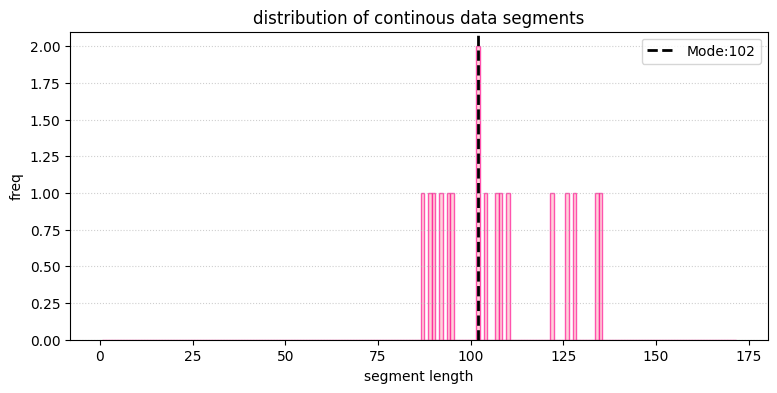

iteration done, moving to size 102
Epoch 1/30
297/297 [==============================] - 5s 14ms/step - loss: 9.8656e-04 - val_loss: 3.3302e-04
Epoch 2/30
297/297 [==============================] - 4s 14ms/step - loss: 1.8993e-04 - val_loss: 2.7181e-04
Epoch 3/30
297/297 [==============================] - 4s 13ms/step - loss: 1.8539e-04 - val_loss: 2.2799e-04
Epoch 4/30
297/297 [==============================] - 4s 14ms/step - loss: 1.8208e-04 - val_loss: 2.1170e-04
Epoch 5/30
297/297 [==============================] - 5s 16ms/step - loss: 1.8186e-04 - val_loss: 2.1136e-04
Epoch 6/30
297/297 [==============================] - 4s 15ms/step - loss: 1.7601e-04 - val_loss: 1.6897e-04
Epoch 7/30
297/297 [==============================] - 5s 16ms/step - loss: 1.8994e-04 - val_loss: 2.8674e-04
Epoch 8/30
297/297 [==============================] - 5s 16ms/step - loss: 1.5499e-04 - val_loss: 1.3426e-04
Epoch 9/30
297/297 [==============================] - 5s 15ms/step - loss: 1.2643e-04 - val_l

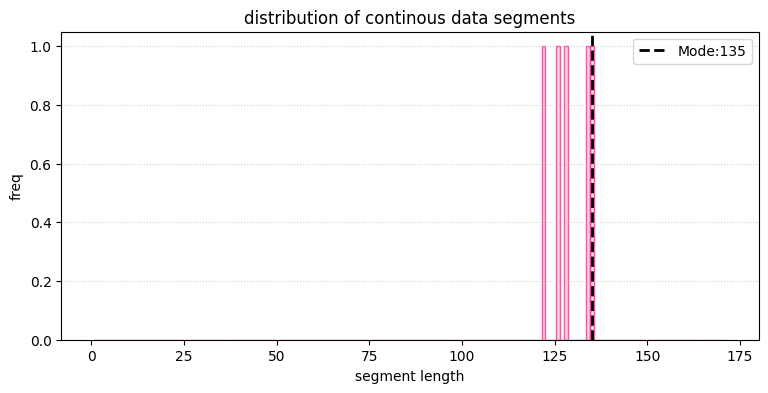

iteration done, moving to size 135
Epoch 1/30
167/167 [==============================] - 5s 22ms/step - loss: 0.0015 - val_loss: 1.7276e-04
Epoch 2/30
167/167 [==============================] - 4s 23ms/step - loss: 1.7562e-04 - val_loss: 2.1522e-04
Epoch 3/30
167/167 [==============================] - 4s 23ms/step - loss: 1.6795e-04 - val_loss: 2.9954e-04
Epoch 4/30
167/167 [==============================] - 4s 23ms/step - loss: 1.5798e-04 - val_loss: 2.3472e-04
Epoch 5/30
167/167 [==============================] - 4s 22ms/step - loss: 1.6591e-04 - val_loss: 3.6107e-04
Epoch 6/30
167/167 [==============================] - 4s 23ms/step - loss: 1.6926e-04 - val_loss: 2.3554e-04
Epoch 7/30
167/167 [==============================] - 4s 22ms/step - loss: 1.5655e-04 - val_loss: 2.8881e-04
Epoch 8/30
167/167 [==============================] - 3s 20ms/step - loss: 1.6544e-04 - val_loss: 3.1301e-04
Epoch 9/30
167/167 [==============================] - 4s 24ms/step - loss: 1.7756e-04 - val_loss:

In [65]:
# updated method with training data from alongshore transects
savepath=r'/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/Figures/R2L_results_prelim/building_up/iteration3'
# grabbing transect for predictions
#transect_df_norm_noDune=transect_df_norm.iloc[200:]
original_baseline_no_dune=transect_73_nodune.copy()
current_dataset=original_baseline_no_dune.copy()
original_data_mask=(~np.isnan(current_dataset)).astype(float)
active_mask=(~np.isnan(current_dataset)).astype(float)
training_ds=selected_transects.copy() # this is no dune
# starting vars
historical_stages_zoo={}
total_iterations=8
current_window_size=10 # start size
pipeline_history={}
summary_stats=[]

for iteration in range (1,total_iterations+1):
    # map of gaps in transect for training (where is there data)
    current_windows_idx=find_windows_of_data(training_ds,window_size=current_window_size,overlap_stride=int(current_window_size/2))
    # prep alongshore transect windows of given size (add in part where you grab inbtween windows) (training data)
    tf_train,tf_val,tf_test=prep_training(train_source_df=training_ds,split_windows_idx=current_windows_idx,batch_size=16)
    # run model
    trained_model,history=run_MAE(window_size=current_window_size,train_ds=tf_train,val_ds=tf_val,epochs=30)
    # reconstruct transect
    reconstructed_df=reconstruct_ds_with_MAE(model=trained_model,current_df=current_dataset,active_mask_df=active_mask,window_size=current_window_size,stride=5)
    # store results
    eval_windows_idx=find_windows_of_data(current_dataset,window_size=current_window_size, overlap_stride=int(current_window_size/2))# need for metrics (where are gaps)
    stage_name=f"stage_{iteration}_size_{current_window_size}"
    historical_stages_zoo[stage_name]=reconstructed_df
    print("plotting error and loss")
    save_stage_loss_plot(history=history,window_size=current_window_size,stage_dir=savepath)
    # update for loop
    current_dataset=reconstructed_df
    active_mask=(~np.isnan(current_dataset)).astype(float)

    # unscale data for plotting
    #recon_phys_df=unscale_dataframe(reconstructed_df,global_scaler)
    #orig_phys_df=transect_df_raw.copy()
    #recon_phys_df[original_baseline_no_dune.isna()]=np.nan
    
    # save stats
    pipeline_history[current_window_size]={"model":trained_model,"history":history,"dataset_after_stage": reconstructed_df.copy()}
    print("plotting static timesteps")
    save_stage_comparison_plots(orig_full_df=transect_73, recon_no_dune_df=reconstructed_df,window_size=current_window_size,stage_dir=savepath)
    print("video of reconstruction")
    save_stage_video_animation(orig_full_df=transect_73, recon_no_dune_df=reconstructed_df,window_size=current_window_size,stage_dir=savepath,interval=500)
    #save_stage_gaps_video_animation(orig_full_df=train_df_norm,recon_no_dune_df=reconstructed_df,window_size=current_window_size,stage_dir=savepath,interval=500)

    # check next window size up
    if iteration<total_iterations:
        floor=current_window_size+10

        current_mode=reeval_and_hist(active_mask_df=active_mask,min_length=floor,target_val=0,plot_histogram=True,stage_label=f"post {stage_name}")

    if current_mode is not None:
        if current_mode<=current_window_size:
            current_window_size=current_window_size+15
        else:
            current_window_size=int(current_mode)

    print(f"iteration done, moving to size {current_mode}")
    
modelname="it3_R2L_MAE"
modelpath=os.path.join(savepath,f"{modelname}.keras")
trained_model.save(modelpath)
print(f"trained model saved to: {modelpath}")

In [66]:
df=pd.concat([transect_73.iloc[:200],reconstructed_df],ignore_index=True)
df_un_norm=unscale_dataframe(df,global_scaler)
df.to_csv("/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/R2L_buildingUp/iteration3_transects_norm.csv",index=False)
df_un_norm.to_csv("/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/R2L_buildingUp/iteration3_transects.csv",index=False)

ITERATION 4: 8 Transects on either side

In [67]:
#Grab transects closest to 7.3 for training
targets = ['transect_y6', 'transect_y8.3','transect_y4','transect_y2','transect_y0','transect_y-2','transect_y10.3','transect_y12.3','transect_y14.3','transect_y16.3','transect_y18.3','transect_y20.3','transect_y22.3''transect_y-4','transect_y-6','transect_y-8']

selected_transects = train_df_norm_nodune.query("transect_name in @targets")
print(selected_transects)

                               0    1    2    3    4    5    6    7    8    \
transect_name  original_index                                                
transect_y-8   0               NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
               1               NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
               2               NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
               3               NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
               4               NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
...                            ...  ...  ...  ...  ...  ...  ...  ...  ...   
transect_y20.3 546             NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
               547             NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
               548             NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
               549             NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
               550             NaN  NaN  NaN  NaN  NaN  NaN  NaN

total windows found: 31832
shortest window: 1
longest window: 431


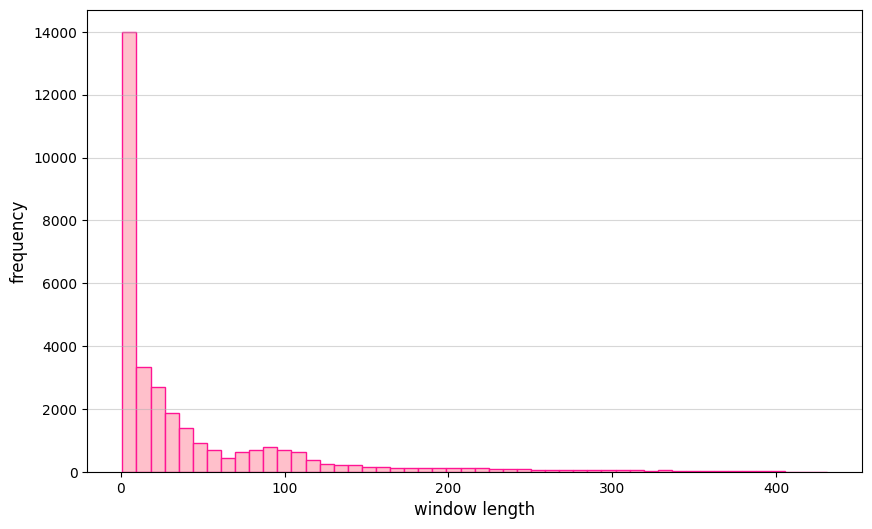

1. length: 11    frequency: 553
2. length: 12    frequency: 543
3. length: 21    frequency: 442
4. length: 25    frequency: 430
5. length: 22    frequency: 408


In [68]:
lengths_by_col,total_lengths_list=what_window_sizes(selected_transects)

print(f"total windows found: {len(total_lengths_list)}")
print(f"shortest window: {np.min(total_lengths_list)}")
print(f"longest window: {np.max(total_lengths_list)}")

plt.figure(figsize=(10,6))

unique_lens=len(set(total_lengths_list))
bins=min(50,unique_lens) if unique_lens>0 else 10

plt.hist(total_lengths_list,bins=bins,color='pink',edgecolor='deeppink')
plt.xlabel('window length',fontsize=12)
plt.ylabel('frequency',fontsize=12)
plt.grid(axis="y",alpha=0.5)
plt.show()

filtered_lengths=[length for length in total_lengths_list if length>10]
length_counts=Counter(filtered_lengths)
top_five=length_counts.most_common(5)

for rank,(length,freq) in enumerate(top_five,1):
    print(f"{rank}. length: {length:<5} frequency: {freq:,}")

Epoch 1/30
9616/9616 [==============================] - 186s 19ms/step - loss: 1.8944e-04 - val_loss: 4.3362e-06
Epoch 2/30
9616/9616 [==============================] - 181s 19ms/step - loss: 4.3130e-05 - val_loss: 8.5099e-06
Epoch 3/30
9616/9616 [==============================] - 176s 18ms/step - loss: 2.5540e-05 - val_loss: 4.1628e-06
Epoch 4/30
9616/9616 [==============================] - 184s 19ms/step - loss: 2.9990e-05 - val_loss: 5.3776e-06
Epoch 5/30
9616/9616 [==============================] - 187s 19ms/step - loss: 2.6060e-05 - val_loss: 2.5161e-06
Epoch 6/30
9616/9616 [==============================] - 179s 19ms/step - loss: 2.3062e-05 - val_loss: 1.9785e-06
Epoch 7/30
9616/9616 [==============================] - 185s 19ms/step - loss: 2.3111e-05 - val_loss: 1.8285e-06
Epoch 8/30
9616/9616 [==============================] - 180s 19ms/step - loss: 2.0119e-05 - val_loss: 3.7573e-06
Epoch 9/30
9616/9616 [==============================] - 172s 18ms/step - loss: 1.9096e-05 - val_

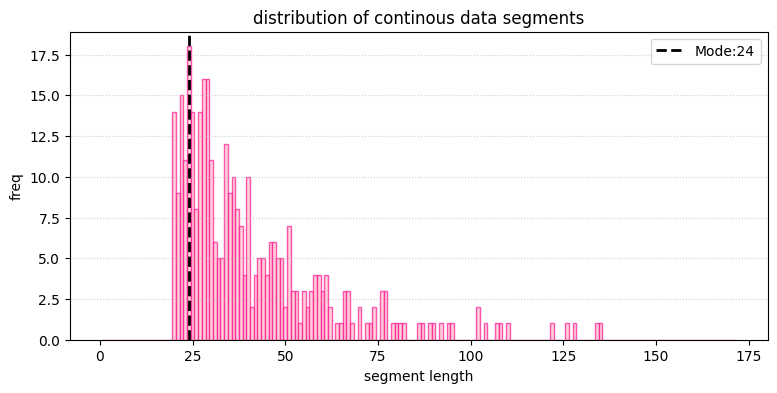

iteration done, moving to size 24
Epoch 1/30
3365/3365 [==============================] - 58s 17ms/step - loss: 2.8478e-04 - val_loss: 1.2654e-05
Epoch 2/30
3365/3365 [==============================] - 57s 17ms/step - loss: 3.5993e-05 - val_loss: 1.1798e-05
Epoch 3/30
3365/3365 [==============================] - 57s 17ms/step - loss: 2.7438e-05 - val_loss: 1.8478e-05
Epoch 4/30
3365/3365 [==============================] - 57s 17ms/step - loss: 3.2023e-05 - val_loss: 1.4515e-05
Epoch 5/30
3365/3365 [==============================] - 59s 17ms/step - loss: 2.2628e-05 - val_loss: 1.3732e-05
Epoch 6/30
3365/3365 [==============================] - 57s 17ms/step - loss: 2.2683e-05 - val_loss: 5.9485e-06
Epoch 7/30
3365/3365 [==============================] - 59s 18ms/step - loss: 2.6115e-05 - val_loss: 8.5273e-06
Epoch 8/30
3365/3365 [==============================] - 58s 17ms/step - loss: 2.4177e-05 - val_loss: 5.6382e-06
Epoch 9/30
3365/3365 [==============================] - 55s 16ms/step 

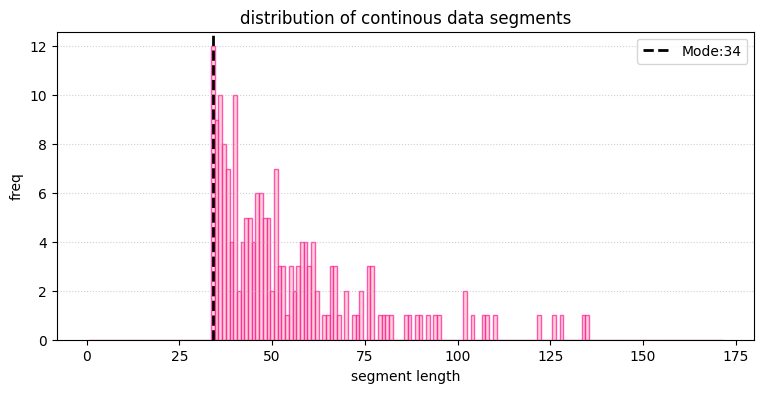

iteration done, moving to size 34
Epoch 1/30
2115/2115 [==============================] - 14s 6ms/step - loss: 3.8462e-04 - val_loss: 4.2899e-05
Epoch 2/30
2115/2115 [==============================] - 13s 6ms/step - loss: 5.1993e-05 - val_loss: 9.1385e-05
Epoch 3/30
2115/2115 [==============================] - 13s 6ms/step - loss: 3.5242e-05 - val_loss: 2.2465e-05
Epoch 4/30
2115/2115 [==============================] - 13s 6ms/step - loss: 3.4632e-05 - val_loss: 1.8519e-05
Epoch 5/30
2115/2115 [==============================] - 13s 6ms/step - loss: 3.1565e-05 - val_loss: 1.2914e-05
Epoch 6/30
2115/2115 [==============================] - 13s 6ms/step - loss: 3.1557e-05 - val_loss: 6.6785e-05
Epoch 7/30
2115/2115 [==============================] - 12s 6ms/step - loss: 2.7405e-05 - val_loss: 1.0483e-05
Epoch 8/30
2115/2115 [==============================] - 13s 6ms/step - loss: 2.4698e-05 - val_loss: 2.2385e-05
Epoch 9/30
2115/2115 [==============================] - 13s 6ms/step - loss: 2

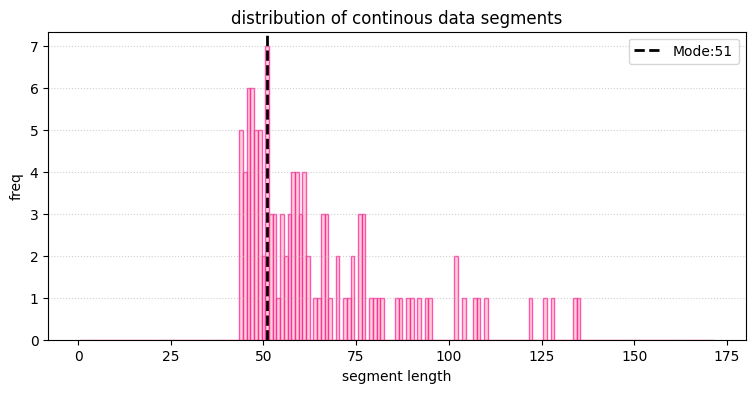

iteration done, moving to size 51
Epoch 1/30
1199/1199 [==============================] - 9s 7ms/step - loss: 4.7424e-04 - val_loss: 2.2862e-04
Epoch 2/30
1199/1199 [==============================] - 8s 6ms/step - loss: 1.5166e-04 - val_loss: 9.8881e-05
Epoch 3/30
1199/1199 [==============================] - 8s 7ms/step - loss: 6.7314e-05 - val_loss: 4.2836e-05
Epoch 4/30
1199/1199 [==============================] - 8s 7ms/step - loss: 4.6152e-05 - val_loss: 3.1789e-05
Epoch 5/30
1199/1199 [==============================] - 8s 7ms/step - loss: 4.1907e-05 - val_loss: 3.0543e-05
Epoch 6/30
1199/1199 [==============================] - 8s 7ms/step - loss: 3.8060e-05 - val_loss: 4.5144e-05
Epoch 7/30
1199/1199 [==============================] - 8s 7ms/step - loss: 3.4418e-05 - val_loss: 1.3900e-05
Epoch 8/30
1199/1199 [==============================] - 8s 7ms/step - loss: 2.8332e-05 - val_loss: 1.3527e-05
Epoch 9/30
1199/1199 [==============================] - 8s 7ms/step - loss: 3.0911e-05

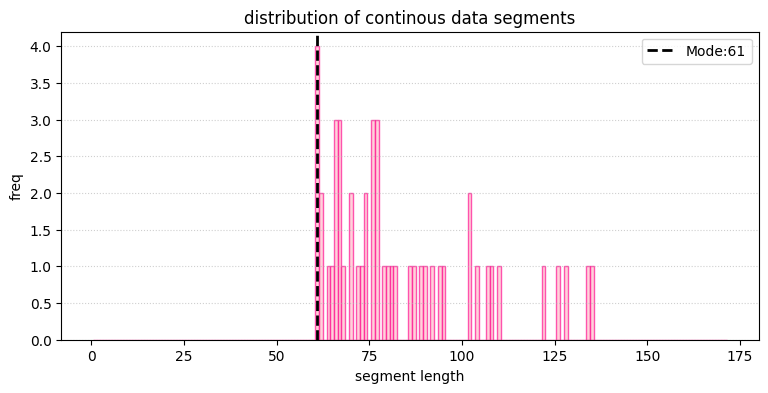

iteration done, moving to size 61
Epoch 1/30
896/896 [==============================] - 9s 9ms/step - loss: 4.6458e-04 - val_loss: 2.1369e-04
Epoch 2/30
896/896 [==============================] - 8s 9ms/step - loss: 1.9023e-04 - val_loss: 8.7347e-05
Epoch 3/30
896/896 [==============================] - 8s 9ms/step - loss: 8.0509e-05 - val_loss: 9.0734e-05
Epoch 4/30
896/896 [==============================] - 9s 10ms/step - loss: 5.4633e-05 - val_loss: 2.1721e-05
Epoch 5/30
896/896 [==============================] - 9s 10ms/step - loss: 4.0259e-05 - val_loss: 2.1047e-05
Epoch 6/30
896/896 [==============================] - 9s 10ms/step - loss: 3.5002e-05 - val_loss: 2.2526e-05
Epoch 7/30
896/896 [==============================] - 9s 10ms/step - loss: 4.3702e-05 - val_loss: 3.6572e-05
Epoch 8/30
896/896 [==============================] - 9s 10ms/step - loss: 2.6745e-05 - val_loss: 6.4003e-05
Epoch 9/30
896/896 [==============================] - 8s 9ms/step - loss: 3.1792e-05 - val_loss: 

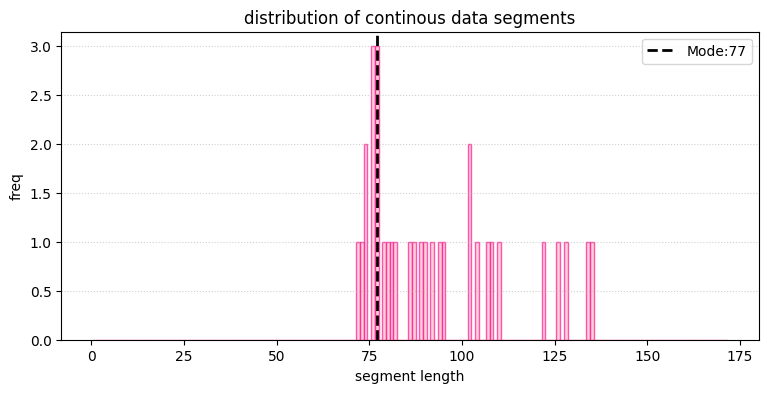

iteration done, moving to size 77
Epoch 1/30
607/607 [==============================] - 9s 13ms/step - loss: 5.8095e-04 - val_loss: 2.2243e-04
Epoch 2/30
607/607 [==============================] - 8s 13ms/step - loss: 1.9589e-04 - val_loss: 2.4707e-04
Epoch 3/30
607/607 [==============================] - 8s 13ms/step - loss: 1.7778e-04 - val_loss: 1.8411e-04
Epoch 4/30
607/607 [==============================] - 8s 13ms/step - loss: 1.1794e-04 - val_loss: 4.6164e-05
Epoch 5/30
607/607 [==============================] - 7s 12ms/step - loss: 5.9438e-05 - val_loss: 3.3681e-05
Epoch 6/30
607/607 [==============================] - 8s 13ms/step - loss: 5.2838e-05 - val_loss: 3.9704e-05
Epoch 7/30
607/607 [==============================] - 8s 13ms/step - loss: 4.8722e-05 - val_loss: 3.7300e-05
Epoch 8/30
607/607 [==============================] - 8s 13ms/step - loss: 3.9845e-05 - val_loss: 3.3436e-05
Epoch 9/30
607/607 [==============================] - 8s 13ms/step - loss: 4.0189e-05 - val_lo

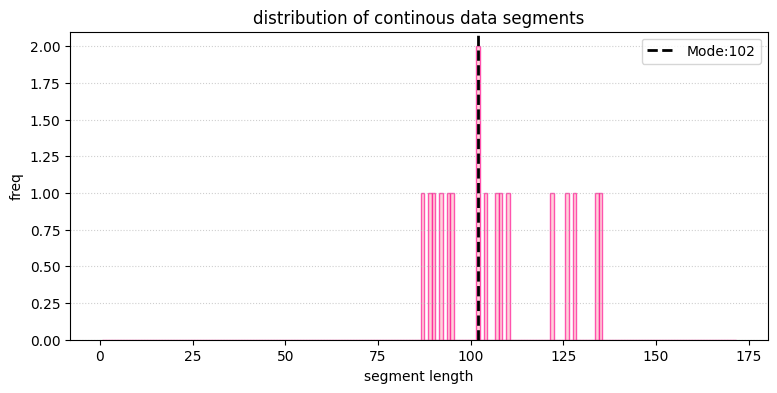

iteration done, moving to size 102
Epoch 1/30
342/342 [==============================] - 6s 14ms/step - loss: 8.6759e-04 - val_loss: 2.0730e-04
Epoch 2/30
342/342 [==============================] - 5s 15ms/step - loss: 1.8557e-04 - val_loss: 2.6955e-04
Epoch 3/30
342/342 [==============================] - 5s 15ms/step - loss: 1.9374e-04 - val_loss: 2.5570e-04
Epoch 4/30
342/342 [==============================] - 5s 14ms/step - loss: 1.8470e-04 - val_loss: 1.7335e-04
Epoch 5/30
342/342 [==============================] - 5s 15ms/step - loss: 1.7945e-04 - val_loss: 3.0323e-04
Epoch 6/30
342/342 [==============================] - 5s 16ms/step - loss: 1.5272e-04 - val_loss: 1.3670e-04
Epoch 7/30
342/342 [==============================] - 5s 16ms/step - loss: 1.0006e-04 - val_loss: 5.0607e-05
Epoch 8/30
342/342 [==============================] - 5s 14ms/step - loss: 7.5979e-05 - val_loss: 5.6364e-05
Epoch 9/30
342/342 [==============================] - 5s 15ms/step - loss: 7.2434e-05 - val_l

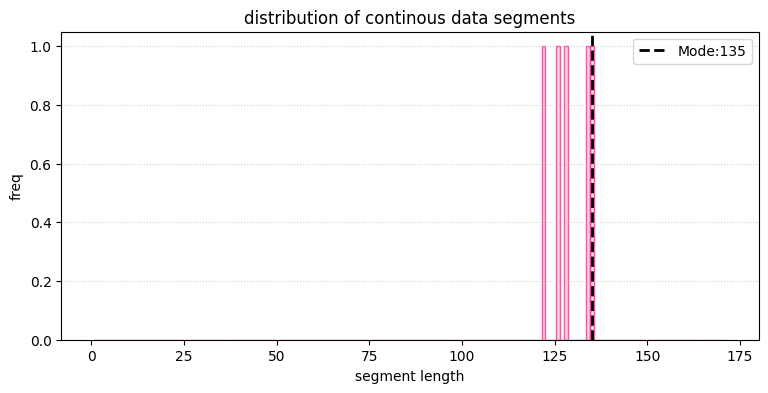

iteration done, moving to size 135
Epoch 1/30
183/183 [==============================] - 4s 20ms/step - loss: 0.0012 - val_loss: 2.3000e-04
Epoch 2/30
183/183 [==============================] - 4s 19ms/step - loss: 1.6290e-04 - val_loss: 2.3247e-04
Epoch 3/30
183/183 [==============================] - 4s 21ms/step - loss: 1.7273e-04 - val_loss: 2.9973e-04
Epoch 4/30
183/183 [==============================] - 4s 19ms/step - loss: 1.7584e-04 - val_loss: 3.9531e-04
Epoch 5/30
183/183 [==============================] - 4s 20ms/step - loss: 1.6357e-04 - val_loss: 5.2665e-04
Epoch 6/30
183/183 [==============================] - 4s 20ms/step - loss: 1.7532e-04 - val_loss: 4.3505e-04
Epoch 7/30
183/183 [==============================] - 3s 18ms/step - loss: 1.5910e-04 - val_loss: 4.6073e-04
Epoch 8/30
183/183 [==============================] - 4s 20ms/step - loss: 1.6676e-04 - val_loss: 4.4615e-04
Epoch 9/30
183/183 [==============================] - 4s 20ms/step - loss: 1.8872e-04 - val_loss:

In [69]:
# updated method with training data from alongshore transects
savepath=r'/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/Figures/R2L_results_prelim/building_up/iteration4'
# grabbing transect for predictions
#transect_df_norm_noDune=transect_df_norm.iloc[200:]
original_baseline_no_dune=transect_73_nodune.copy()
current_dataset=original_baseline_no_dune.copy()
original_data_mask=(~np.isnan(current_dataset)).astype(float)
active_mask=(~np.isnan(current_dataset)).astype(float)
training_ds=selected_transects.copy() # this is no dune
# starting vars
historical_stages_zoo={}
total_iterations=8
current_window_size=10 # start size
pipeline_history={}
summary_stats=[]

for iteration in range (1,total_iterations+1):
    # map of gaps in transect for training (where is there data)
    current_windows_idx=find_windows_of_data(training_ds,window_size=current_window_size,overlap_stride=int(current_window_size/2))
    # prep alongshore transect windows of given size (add in part where you grab inbtween windows) (training data)
    tf_train,tf_val,tf_test=prep_training(train_source_df=training_ds,split_windows_idx=current_windows_idx,batch_size=16)
    # run model
    trained_model,history=run_MAE(window_size=current_window_size,train_ds=tf_train,val_ds=tf_val,epochs=30)
    # reconstruct transect
    reconstructed_df=reconstruct_ds_with_MAE(model=trained_model,current_df=current_dataset,active_mask_df=active_mask,window_size=current_window_size,stride=5)
    # store results
    eval_windows_idx=find_windows_of_data(current_dataset,window_size=current_window_size, overlap_stride=int(current_window_size/2))# need for metrics (where are gaps)
    stage_name=f"stage_{iteration}_size_{current_window_size}"
    historical_stages_zoo[stage_name]=reconstructed_df
    print("plotting error and loss")
    save_stage_loss_plot(history=history,window_size=current_window_size,stage_dir=savepath)
    # update for loop
    current_dataset=reconstructed_df
    active_mask=(~np.isnan(current_dataset)).astype(float)

    # unscale data for plotting
    #recon_phys_df=unscale_dataframe(reconstructed_df,global_scaler)
    #orig_phys_df=transect_df_raw.copy()
    #recon_phys_df[original_baseline_no_dune.isna()]=np.nan
    
    # save stats
    pipeline_history[current_window_size]={"model":trained_model,"history":history,"dataset_after_stage": reconstructed_df.copy()}
    print("plotting static timesteps")
    save_stage_comparison_plots(orig_full_df=transect_73, recon_no_dune_df=reconstructed_df,window_size=current_window_size,stage_dir=savepath)
    print("video of reconstruction")
    save_stage_video_animation(orig_full_df=transect_73, recon_no_dune_df=reconstructed_df,window_size=current_window_size,stage_dir=savepath,interval=500)
    #save_stage_gaps_video_animation(orig_full_df=train_df_norm,recon_no_dune_df=reconstructed_df,window_size=current_window_size,stage_dir=savepath,interval=500)

    # check next window size up
    if iteration<total_iterations:
        floor=current_window_size+10

        current_mode=reeval_and_hist(active_mask_df=active_mask,min_length=floor,target_val=0,plot_histogram=True,stage_label=f"post {stage_name}")

    if current_mode is not None:
        if current_mode<=current_window_size:
            current_window_size=current_window_size+15
        else:
            current_window_size=int(current_mode)

    print(f"iteration done, moving to size {current_mode}")
    
modelname="it4_R2L_MAE"
modelpath=os.path.join(savepath,f"{modelname}.keras")
trained_model.save(modelpath)
print(f"trained model saved to: {modelpath}")

In [70]:
df=pd.concat([transect_73.iloc[:200],reconstructed_df],ignore_index=True)
df_un_norm=unscale_dataframe(df,global_scaler)
df.to_csv("/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/R2L_buildingUp/iteration4_transects_norm.csv",index=False)
df_un_norm.to_csv("/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/R2L_buildingUp/iteration4_transects.csv",index=False)

ITERATION 5: All Transects

total windows found: 119449
shortest window: 1
longest window: 431


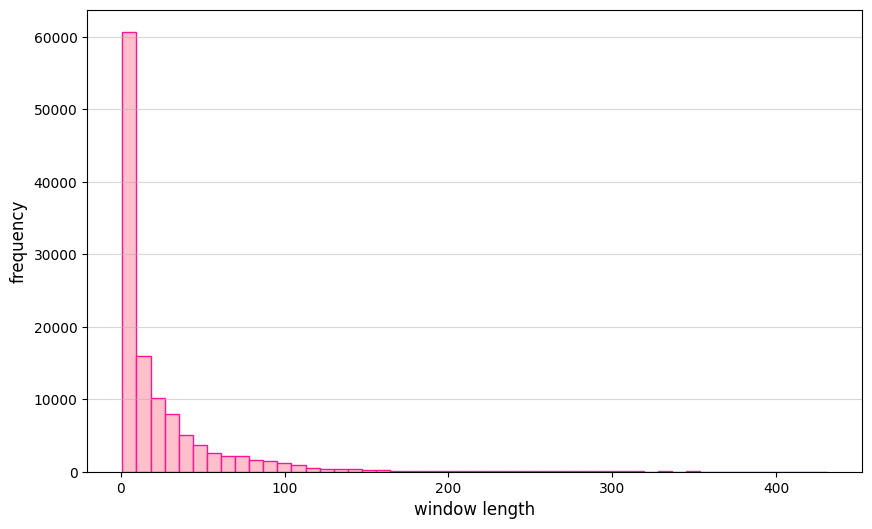

1. length: 11    frequency: 2,191
2. length: 12    frequency: 2,017
3. length: 13    frequency: 1,744
4. length: 14    frequency: 1,693
5. length: 17    frequency: 1,579


In [71]:
lengths_by_col,total_lengths_list=what_window_sizes(train_ds)

print(f"total windows found: {len(total_lengths_list)}")
print(f"shortest window: {np.min(total_lengths_list)}")
print(f"longest window: {np.max(total_lengths_list)}")

plt.figure(figsize=(10,6))

unique_lens=len(set(total_lengths_list))
bins=min(50,unique_lens) if unique_lens>0 else 10

plt.hist(total_lengths_list,bins=bins,color='pink',edgecolor='deeppink')
plt.xlabel('window length',fontsize=12)
plt.ylabel('frequency',fontsize=12)
plt.grid(axis="y",alpha=0.5)
plt.show()

filtered_lengths=[length for length in total_lengths_list if length>10]
length_counts=Counter(filtered_lengths)
top_five=length_counts.most_common(5)

for rank,(length,freq) in enumerate(top_five,1):
    print(f"{rank}. length: {length:<5} frequency: {freq:,}")

Epoch 1/30
19721/19721 [==============================] - 324s 16ms/step - loss: 1.4082e-04 - val_loss: 1.1138e-05
Epoch 2/30
19721/19721 [==============================] - 334s 17ms/step - loss: 2.1721e-05 - val_loss: 1.0654e-05
Epoch 3/30
19721/19721 [==============================] - 340s 17ms/step - loss: 1.8612e-05 - val_loss: 3.1809e-06
Epoch 4/30
19721/19721 [==============================] - 345s 17ms/step - loss: 1.7279e-05 - val_loss: 5.4232e-06
Epoch 5/30
19721/19721 [==============================] - 340s 17ms/step - loss: 1.4806e-05 - val_loss: 2.5629e-06
Epoch 6/30
19721/19721 [==============================] - 363s 18ms/step - loss: 1.5026e-05 - val_loss: 4.3055e-06
Epoch 7/30
19721/19721 [==============================] - 302s 15ms/step - loss: 1.5717e-05 - val_loss: 1.0140e-06
Epoch 8/30
19721/19721 [==============================] - 325s 16ms/step - loss: 1.4232e-05 - val_loss: 1.1591e-06
Epoch 9/30
19721/19721 [==============================] - 327s 17ms/step - loss:

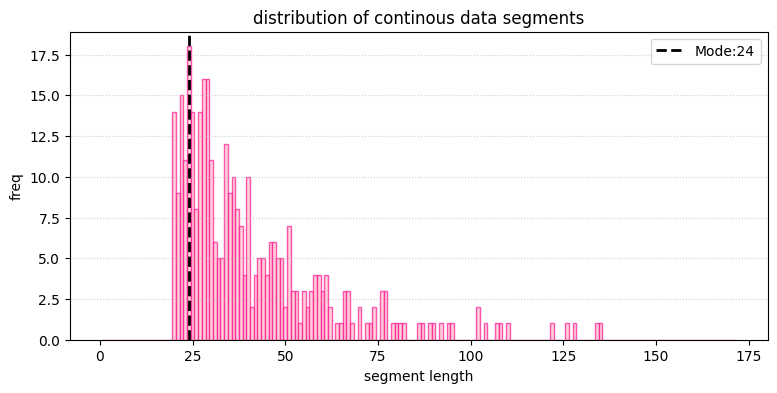

iteration done, moving to size 24
Epoch 1/30
6159/6159 [==============================] - 122s 20ms/step - loss: 2.2879e-04 - val_loss: 1.4724e-05
Epoch 2/30
6159/6159 [==============================] - 122s 20ms/step - loss: 2.8249e-05 - val_loss: 8.2738e-06
Epoch 3/30
6159/6159 [==============================] - 124s 20ms/step - loss: 2.3657e-05 - val_loss: 4.3955e-06
Epoch 4/30
6159/6159 [==============================] - 119s 19ms/step - loss: 1.9935e-05 - val_loss: 1.4388e-05
Epoch 5/30
6159/6159 [==============================] - 111s 18ms/step - loss: 1.9362e-05 - val_loss: 1.0603e-05
Epoch 6/30
6159/6159 [==============================] - 114s 18ms/step - loss: 1.7855e-05 - val_loss: 4.9239e-06
Epoch 7/30
6159/6159 [==============================] - 119s 19ms/step - loss: 1.4482e-05 - val_loss: 5.8079e-06
Epoch 8/30
6159/6159 [==============================] - 115s 19ms/step - loss: 1.5208e-05 - val_loss: 3.8972e-06
Epoch 9/30
6159/6159 [==============================] - 110s 1

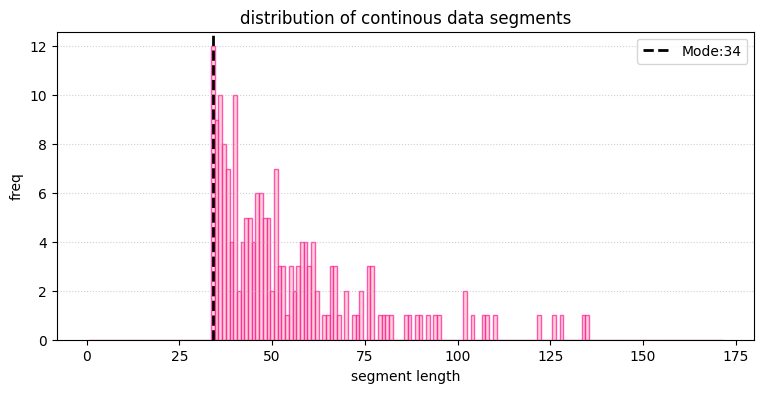

iteration done, moving to size 34
Epoch 1/30
3588/3588 [==============================] - 21s 6ms/step - loss: 3.5120e-04 - val_loss: 8.5177e-05
Epoch 2/30
3588/3588 [==============================] - 18s 5ms/step - loss: 4.9784e-05 - val_loss: 2.4307e-05
Epoch 3/30
3588/3588 [==============================] - 18s 5ms/step - loss: 3.3823e-05 - val_loss: 1.2748e-05
Epoch 4/30
3588/3588 [==============================] - 19s 5ms/step - loss: 2.8161e-05 - val_loss: 1.5825e-05
Epoch 5/30
3588/3588 [==============================] - 18s 5ms/step - loss: 2.2147e-05 - val_loss: 1.4647e-05
Epoch 6/30
3588/3588 [==============================] - 19s 5ms/step - loss: 1.9056e-05 - val_loss: 1.4207e-05
Epoch 7/30
3588/3588 [==============================] - 19s 5ms/step - loss: 2.3516e-05 - val_loss: 1.0803e-05
Epoch 8/30
3588/3588 [==============================] - 19s 5ms/step - loss: 2.3082e-05 - val_loss: 1.0402e-05
Epoch 9/30
3588/3588 [==============================] - 20s 6ms/step - loss: 2

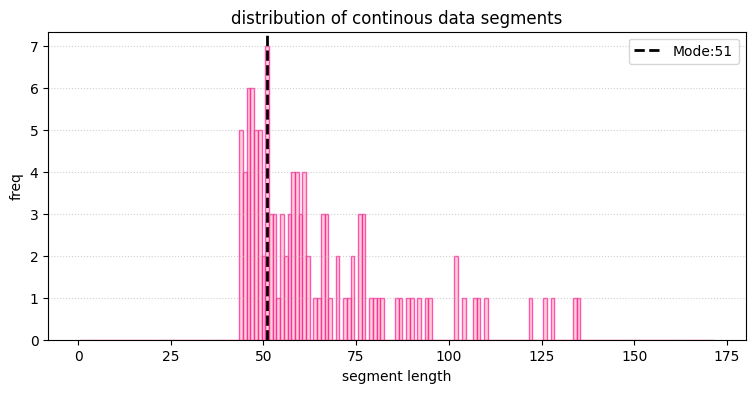

iteration done, moving to size 51
Epoch 1/30
1806/1806 [==============================] - 13s 7ms/step - loss: 3.8806e-04 - val_loss: 1.5284e-04
Epoch 2/30
1806/1806 [==============================] - 12s 7ms/step - loss: 2.1630e-04 - val_loss: 8.2606e-05
Epoch 3/30
1806/1806 [==============================] - 12s 7ms/step - loss: 5.2608e-05 - val_loss: 3.7698e-05
Epoch 4/30
1806/1806 [==============================] - 13s 7ms/step - loss: 3.5418e-05 - val_loss: 8.7024e-05
Epoch 5/30
1806/1806 [==============================] - 13s 7ms/step - loss: 2.9017e-05 - val_loss: 3.7376e-05
Epoch 6/30
1806/1806 [==============================] - 13s 7ms/step - loss: 2.9283e-05 - val_loss: 1.7551e-05
Epoch 7/30
1806/1806 [==============================] - 14s 8ms/step - loss: 2.8853e-05 - val_loss: 3.1452e-05
Epoch 8/30
1806/1806 [==============================] - 13s 7ms/step - loss: 2.2887e-05 - val_loss: 4.7059e-05
Epoch 9/30
1806/1806 [==============================] - 14s 8ms/step - loss: 2

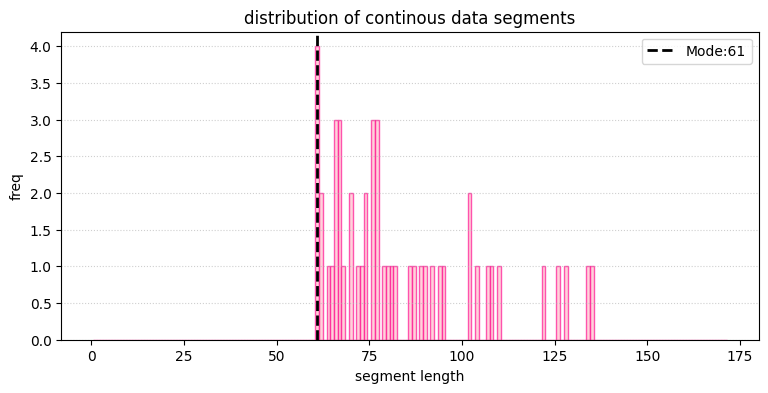

iteration done, moving to size 61
Epoch 1/30
1291/1291 [==============================] - 11s 8ms/step - loss: 4.0905e-04 - val_loss: 2.1240e-04
Epoch 2/30
1291/1291 [==============================] - 12s 9ms/step - loss: 1.9229e-04 - val_loss: 1.1053e-04
Epoch 3/30
1291/1291 [==============================] - 10s 7ms/step - loss: 4.7667e-05 - val_loss: 3.0260e-05
Epoch 4/30
1291/1291 [==============================] - 10s 7ms/step - loss: 3.8026e-05 - val_loss: 3.4807e-05
Epoch 5/30
1291/1291 [==============================] - 10s 8ms/step - loss: 3.0301e-05 - val_loss: 2.3011e-05
Epoch 6/30
1291/1291 [==============================] - 10s 8ms/step - loss: 3.1405e-05 - val_loss: 8.4725e-06
Epoch 7/30
1291/1291 [==============================] - 10s 8ms/step - loss: 2.6557e-05 - val_loss: 7.8782e-06
Epoch 8/30
1291/1291 [==============================] - 11s 8ms/step - loss: 3.0411e-05 - val_loss: 1.8935e-05
Epoch 9/30
1291/1291 [==============================] - 11s 8ms/step - loss: 2

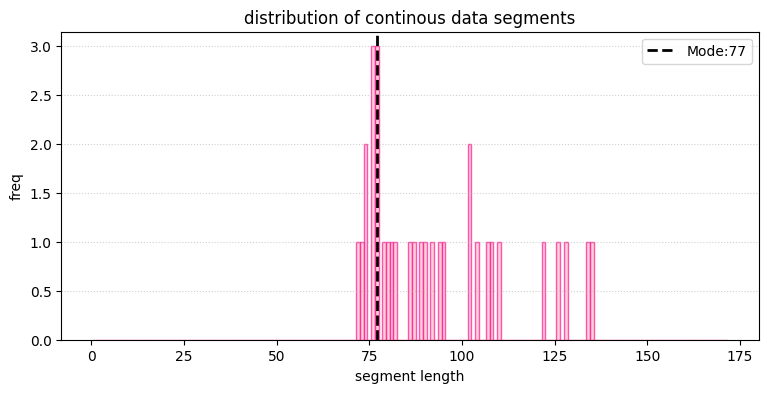

iteration done, moving to size 77
Epoch 1/30
785/785 [==============================] - 9s 11ms/step - loss: 4.8729e-04 - val_loss: 3.4156e-04
Epoch 2/30
785/785 [==============================] - 8s 11ms/step - loss: 1.8955e-04 - val_loss: 2.1805e-04
Epoch 3/30
785/785 [==============================] - 8s 11ms/step - loss: 1.1812e-04 - val_loss: 9.2846e-05
Epoch 4/30
785/785 [==============================] - 9s 11ms/step - loss: 6.5258e-05 - val_loss: 2.8592e-05
Epoch 5/30
785/785 [==============================] - 8s 10ms/step - loss: 5.8576e-05 - val_loss: 5.0075e-05
Epoch 6/30
785/785 [==============================] - 9s 11ms/step - loss: 4.8498e-05 - val_loss: 2.4997e-05
Epoch 7/30
785/785 [==============================] - 8s 10ms/step - loss: 4.3379e-05 - val_loss: 1.6223e-05
Epoch 8/30
785/785 [==============================] - 8s 11ms/step - loss: 4.1164e-05 - val_loss: 6.5884e-05
Epoch 9/30
785/785 [==============================] - 8s 10ms/step - loss: 3.9077e-05 - val_lo

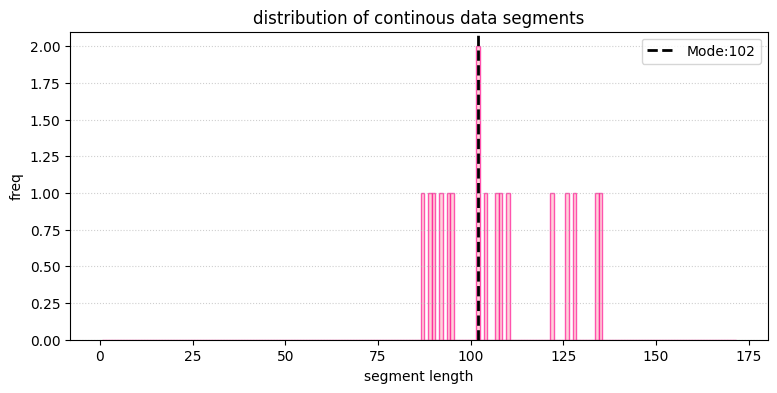

iteration done, moving to size 102
Epoch 1/30
398/398 [==============================] - 6s 12ms/step - loss: 8.7180e-04 - val_loss: 2.6495e-04
Epoch 2/30
398/398 [==============================] - 4s 11ms/step - loss: 1.8636e-04 - val_loss: 2.5890e-04
Epoch 3/30
398/398 [==============================] - 5s 12ms/step - loss: 1.9078e-04 - val_loss: 2.4397e-04
Epoch 4/30
398/398 [==============================] - 4s 11ms/step - loss: 1.8754e-04 - val_loss: 2.5002e-04
Epoch 5/30
398/398 [==============================] - 4s 11ms/step - loss: 1.8481e-04 - val_loss: 2.7337e-04
Epoch 6/30
398/398 [==============================] - 5s 11ms/step - loss: 1.8368e-04 - val_loss: 1.9920e-04
Epoch 7/30
398/398 [==============================] - 5s 12ms/step - loss: 1.2378e-04 - val_loss: 1.1142e-04
Epoch 8/30
398/398 [==============================] - 5s 12ms/step - loss: 7.9052e-05 - val_loss: 5.5270e-05
Epoch 9/30
398/398 [==============================] - 5s 12ms/step - loss: 6.6925e-05 - val_l

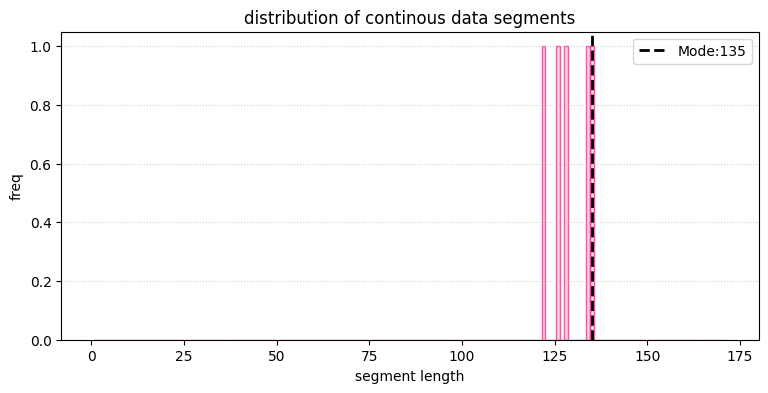

iteration done, moving to size 135
Epoch 1/30
202/202 [==============================] - 5s 22ms/step - loss: 0.0012 - val_loss: 3.0753e-04
Epoch 2/30
202/202 [==============================] - 4s 21ms/step - loss: 1.7769e-04 - val_loss: 5.1799e-04
Epoch 3/30
202/202 [==============================] - 4s 20ms/step - loss: 1.7922e-04 - val_loss: 5.6793e-04
Epoch 4/30
202/202 [==============================] - 4s 19ms/step - loss: 1.5943e-04 - val_loss: 4.2906e-04
Epoch 5/30
202/202 [==============================] - 4s 21ms/step - loss: 1.7346e-04 - val_loss: 4.6965e-04
Epoch 6/30
202/202 [==============================] - 4s 21ms/step - loss: 1.8216e-04 - val_loss: 4.8002e-04
Epoch 7/30
202/202 [==============================] - 4s 19ms/step - loss: 1.5982e-04 - val_loss: 4.4501e-04
Epoch 8/30
202/202 [==============================] - 4s 21ms/step - loss: 1.6473e-04 - val_loss: 4.7914e-04
Epoch 9/30
202/202 [==============================] - 4s 19ms/step - loss: 1.8452e-04 - val_loss:

In [72]:
# updated method with training data from alongshore transects
savepath=r'/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/Figures/R2L_results_prelim/building_up/iteration5'
# grabbing transect for predictions
#transect_df_norm_noDune=transect_df_norm.iloc[200:]
original_baseline_no_dune=transect_73_nodune.copy()
current_dataset=original_baseline_no_dune.copy()
original_data_mask=(~np.isnan(current_dataset)).astype(float)
active_mask=(~np.isnan(current_dataset)).astype(float)
training_ds=train_df_norm_nodune.copy() # this is no dune
# starting vars
historical_stages_zoo={}
total_iterations=8
current_window_size=10 # start size
pipeline_history={}
summary_stats=[]

for iteration in range (1,total_iterations+1):
    # map of gaps in transect for training (where is there data)
    current_windows_idx=find_windows_of_data(training_ds,window_size=current_window_size,overlap_stride=int(current_window_size/2))
    # prep alongshore transect windows of given size (add in part where you grab inbtween windows) (training data)
    tf_train,tf_val,tf_test=prep_training(train_source_df=training_ds,split_windows_idx=current_windows_idx,batch_size=16)
    # run model
    trained_model,history=run_MAE(window_size=current_window_size,train_ds=tf_train,val_ds=tf_val,epochs=30)
    # reconstruct transect
    reconstructed_df=reconstruct_ds_with_MAE(model=trained_model,current_df=current_dataset,active_mask_df=active_mask,window_size=current_window_size,stride=5)
    # store results
    eval_windows_idx=find_windows_of_data(current_dataset,window_size=current_window_size, overlap_stride=int(current_window_size/2))# need for metrics (where are gaps)
    stage_name=f"stage_{iteration}_size_{current_window_size}"
    historical_stages_zoo[stage_name]=reconstructed_df
    print("plotting error and loss")
    save_stage_loss_plot(history=history,window_size=current_window_size,stage_dir=savepath)
    # update for loop
    current_dataset=reconstructed_df
    active_mask=(~np.isnan(current_dataset)).astype(float)

    # unscale data for plotting
    #recon_phys_df=unscale_dataframe(reconstructed_df,global_scaler)
    #orig_phys_df=transect_df_raw.copy()
    #recon_phys_df[original_baseline_no_dune.isna()]=np.nan
    
    # save stats
    pipeline_history[current_window_size]={"model":trained_model,"history":history,"dataset_after_stage": reconstructed_df.copy()}
    print("plotting static timesteps")
    save_stage_comparison_plots(orig_full_df=transect_73, recon_no_dune_df=reconstructed_df,window_size=current_window_size,stage_dir=savepath)
    print("video of reconstruction")
    save_stage_video_animation(orig_full_df=transect_73, recon_no_dune_df=reconstructed_df,window_size=current_window_size,stage_dir=savepath,interval=500)
    #save_stage_gaps_video_animation(orig_full_df=train_df_norm,recon_no_dune_df=reconstructed_df,window_size=current_window_size,stage_dir=savepath,interval=500)

    # check next window size up
    if iteration<total_iterations:
        floor=current_window_size+10

        current_mode=reeval_and_hist(active_mask_df=active_mask,min_length=floor,target_val=0,plot_histogram=True,stage_label=f"post {stage_name}")

    if current_mode is not None:
        if current_mode<=current_window_size:
            current_window_size=current_window_size+15
        else:
            current_window_size=int(current_mode)

    print(f"iteration done, moving to size {current_mode}")
    
modelname="it5_R2L_MAE"
modelpath=os.path.join(savepath,f"{modelname}.keras")
trained_model.save(modelpath)
print(f"trained model saved to: {modelpath}")

In [73]:
df=pd.concat([transect_73.iloc[:200],reconstructed_df],ignore_index=True)
df_un_norm=unscale_dataframe(df,global_scaler)
df.to_csv("/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/R2L_buildingUp/iteration5_transects_norm.csv",index=False)
df_un_norm.to_csv("/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/R2L_buildingUp/iteration5_transects.csv",index=False)

Compare results from each iteration

In [74]:
savepath=r"/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/Figures/R2L_results_prelim/building_up/comparison"

path1=r"/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/R2L_buildingUp/iteration1_transects_norm.csv"
path2=r"/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/R2L_buildingUp/iteration2_transects_norm.csv"
path3=r"/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/R2L_buildingUp/iteration3_transects_norm.csv"
path4=r"/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/R2L_buildingUp/iteration4_transects_norm.csv"
path5=r"/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/R2L_buildingUp/iteration5_transects_norm.csv"

nit1=pd.read_csv(path1)
nit2=pd.read_csv(path2)
nit3=pd.read_csv(path3)
nit4=pd.read_csv(path4)
nit5=pd.read_csv(path5)

path1=r"/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/R2L_buildingUp/iteration1_transects.csv"
path2=r"/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/R2L_buildingUp/iteration2_transects.csv"
path3=r"/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/R2L_buildingUp/iteration3_transects.csv"
path4=r"/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/R2L_buildingUp/iteration4_transects.csv"
path5=r"/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/R2L_buildingUp/iteration5_transects.csv"

it1=pd.read_csv(path1)
it2=pd.read_csv(path2)
it3=pd.read_csv(path3)
it4=pd.read_csv(path4)
it5=pd.read_csv(path5)

print(it1.shape)
print(it2.shape)
print(it3.shape)
print(it4.shape)
print(it5.shape)

(551, 239)
(551, 239)
(551, 239)
(551, 239)
(551, 239)


In [75]:
def save_comp_video_animation(
    orig_full_df,
    recon1_df,
    recon2_df,
    recon3_df,
    recon4_df,
    recon5_df,
    model_names,  # e.g., ('L2R','R2L',..)
    stage_dir="stage_outputs",
    interval=500
):
    """
    Creates and saves a dynamic video tracking 3 different profile repairs over time
    across the entire cross-shore profile (no dune offset).
    """
    os.makedirs(stage_dir, exist_ok=True)
   
    orig_full_data = orig_full_df.values
    recon1_data = recon1_df.values
    recon2_data = recon2_df.values
    recon3_data = recon3_df.values
    recon4_data=recon4_df.values
    recon5_data=recon5_df.values
   
    n_points, n_timesteps = orig_full_data.shape
    x_coords = np.arange(n_points)

    fig, ax = plt.subplots(figsize=(10, 4))
   
    # Set standard layout constraints based on full dataset limits
    ax.set_xlim(0, n_points)
    #ax.set_ylim(0,1)
    ax.set_ylim(np.nanmin(orig_full_data) - 0.1,5)# np.nanmax(orig_full_data) + 0.1)
    ax.set_xlabel("Cross-shore index")
    ax.set_ylabel("Elevation (m)")
   
    # Initialize baseline handles
    #line_orig, = ax.plot([], [], color='peachpuff', alpha=0.6, linewidth=1.5, label='Original Data')
   
    # 3 Reconstruction Lines
    line_recon1, = ax.plot([], [], color='deeppink', linewidth=2, label=f'MAE-{model_names[0]} Reconstruction')
    line_recon2, = ax.plot([], [], color='darkorange', linewidth=2, label=f'MAE-{model_names[1]} Reconstruction')
    line_recon3, = ax.plot([], [], color='gold', linewidth=2, label=f'MAE-{model_names[2]} Reconstruction')
    line_recon4, = ax.plot([], [], color='springgreen', linewidth=2, label=f'MAE-{model_names[3]} Reconstruction')
    line_recon5, = ax.plot([], [], color='skyblue', linewidth=2, label=f'MAE-{model_names[4]} Reconstruction')
    line_orig, = ax.plot([], [], color='black', alpha=0.6, linewidth=1.5, label='Original Data')

    # Gaps as highlights patch for legend
    gap_patch = plt.Rectangle((0,0), 1, 1, fc="gray", alpha=0.3, label='Gaps')
   
    # Include all lines in the legend
    ax.legend(handles=[line_orig, line_recon1, line_recon2, line_recon3,line_recon4,line_recon5, gap_patch], bbox_to_anchor=(0.5,-0.15),ncol=2)
    #ax.legend(handles=[line_orig, line_recon1, line_recon2, gap_patch], loc='lower left')
    plt.tight_layout()

    gap_spans = []

    def update(frame):
        nonlocal gap_spans
        # Clear previous frame's gap highlights
        for span in gap_spans:
            span.remove()
        gap_spans.clear()
       
        y_orig = orig_full_data[:, frame]
       
        # Direct assignment (no stitching needed)
        y_recon1_full = recon1_data[:, frame]
        y_recon2_full = recon2_data[:, frame]
        y_recon3_full = recon3_data[:, frame]
        y_recon4_full = recon4_data[:, frame]
        y_recon5_full = recon5_data[:, frame]

        # Calculate gaps based on the entire original survey data
        is_gap = np.isnan(y_orig)

        if np.any(is_gap):
            diff = np.diff(is_gap.astype(int))
            gap_starts = np.where(diff == 1)[0] + 1
            gap_ends = np.where(diff == -1)[0] + 1

            if is_gap[0]:
                gap_starts = np.insert(gap_starts, 0, 0)
            if is_gap[-1]:
                gap_ends = np.append(gap_ends, n_points - 1)

            for start, end in zip(gap_starts, gap_ends):
                span = ax.axvspan(start, end, color='gray', alpha=0.25, zorder=0)
                gap_spans.append(span)

        # Update line data for all 4 profiles
        
        line_recon1.set_data(x_coords, y_recon1_full)
        line_recon2.set_data(x_coords, y_recon2_full)
        line_recon3.set_data(x_coords, y_recon3_full)
        line_recon4.set_data(x_coords, y_recon4_full)
        line_recon5.set_data(x_coords, y_recon5_full)
        line_orig.set_data(x_coords, y_orig)
       
        ax.set_title(f"Comparison of Full Reconstructions | Timestep: {frame}")
       
        return [line_recon1, line_recon2,line_orig] + gap_spans

    anim = FuncAnimation(fig, update, frames=n_timesteps, interval=interval, blit=True)
   
    video_path = os.path.join(stage_dir, f"compare_training_iterations.gif")
    anim.save(video_path, writer="pillow")
    plt.close()

In [76]:
savepath=r"/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/Figures/L2R_results_prelim/building_upL2R/comparison"

path1=r"/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/L2R_buildingUp/iteration1_transects_norm.csv"
path2=r"/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/L2R_buildingUp/iteration2_transects_norm.csv"
path3=r"/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/L2R_buildingUp/iteration3_transects_norm.csv"
path4=r"/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/L2R_buildingUp/iteration4_transects_norm.csv"
path5=r"/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/L2R_buildingUp/iteration5_transects_norm.csv"

nit1=pd.read_csv(path1)
nit2=pd.read_csv(path2)
nit3=pd.read_csv(path3)
nit4=pd.read_csv(path4)
nit5=pd.read_csv(path5)

path1=r"/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/L2R_buildingUp/iteration1_transects.csv"
path2=r"/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/L2R_buildingUp/iteration2_transects.csv"
path3=r"/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/L2R_buildingUp/iteration3_transects.csv"
path4=r"/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/L2R_buildingUp/iteration4_transects.csv"
path5=r"/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/L2R_buildingUp/iteration5_transects.csv"

it1=pd.read_csv(path1)
it2=pd.read_csv(path2)
it3=pd.read_csv(path3)
it4=pd.read_csv(path4)
it5=pd.read_csv(path5)

print(it1.shape)
print(it2.shape)
print(it3.shape)
print(it4.shape)
print(it5.shape)

(551, 239)
(551, 239)
(551, 239)
(551, 239)
(551, 239)


In [77]:
def save_norm_comp_video_animation(
    orig_full_df,
    recon1_df,
    recon2_df,
    recon3_df,
    recon4_df,
    recon5_df,
    model_names,  # e.g., ('L2R','R2L',..)
    stage_dir="stage_outputs",
    interval=500
):
    """
    Creates and saves a dynamic video tracking 3 different profile repairs over time
    across the entire cross-shore profile (no dune offset).
    """
    os.makedirs(stage_dir, exist_ok=True)
   
    orig_full_data = orig_full_df.values
    recon1_data = recon1_df.values
    recon2_data = recon2_df.values
    recon3_data = recon3_df.values
    recon4_data=recon4_df.values
    recon5_data=recon5_df.values
   
    n_points, n_timesteps = orig_full_data.shape
    x_coords = np.arange(n_points)

    fig, ax = plt.subplots(figsize=(10, 4))
   
    # Set standard layout constraints based on full dataset limits
    ax.set_xlim(0, n_points)
    #ax.set_ylim(0,1)
    ax.set_ylim(np.nanmin(orig_full_data) - 0.1,0.8)# np.nanmax(orig_full_data) + 0.1)
    ax.set_xlabel("Cross-shore index")
    ax.set_ylabel("Normalized Elevation (m)")
   
    # Initialize baseline handles
    #line_orig, = ax.plot([], [], color='peachpuff', alpha=0.6, linewidth=1.5, label='Original Data')
   
    # 3 Reconstruction Lines
    line_recon1, = ax.plot([], [], color='deeppink', linewidth=2, label=f'MAE-{model_names[0]} Reconstruction')
    line_recon2, = ax.plot([], [], color='darkorange', linewidth=2, label=f'MAE-{model_names[1]} Reconstruction')
    line_recon3, = ax.plot([], [], color='gold', linewidth=2, label=f'MAE-{model_names[2]} Reconstruction')
    line_recon4, = ax.plot([], [], color='springgreen', linewidth=2, label=f'MAE-{model_names[3]} Reconstruction')
    line_recon5, = ax.plot([], [], color='skyblue', linewidth=2, label=f'MAE-{model_names[4]} Reconstruction')
    line_orig, = ax.plot([], [], color='black', alpha=0.6, linewidth=1.5, label='Original Data')

    # Gaps as highlights patch for legend
    gap_patch = plt.Rectangle((0,0), 1, 1, fc="gray", alpha=0.3, label='Gaps')
   
    # Include all lines in the legend
    ax.legend(handles=[line_orig, line_recon1, line_recon2, line_recon3,line_recon4,line_recon5, gap_patch], bbox_to_anchor=(0.5,-0.15),ncol=2)
    #ax.legend(handles=[line_orig, line_recon1, line_recon2, gap_patch], loc='lower left')
    plt.tight_layout()

    gap_spans = []

    def update(frame):
        nonlocal gap_spans
        # Clear previous frame's gap highlights
        for span in gap_spans:
            span.remove()
        gap_spans.clear()
       
        y_orig = orig_full_data[:, frame]
       
        # Direct assignment (no stitching needed)
        y_recon1_full = recon1_data[:, frame]
        y_recon2_full = recon2_data[:, frame]
        y_recon3_full = recon3_data[:, frame]
        y_recon4_full = recon4_data[:, frame]
        y_recon5_full = recon5_data[:, frame]

        # Calculate gaps based on the entire original survey data
        is_gap = np.isnan(y_orig)

        if np.any(is_gap):
            diff = np.diff(is_gap.astype(int))
            gap_starts = np.where(diff == 1)[0] + 1
            gap_ends = np.where(diff == -1)[0] + 1

            if is_gap[0]:
                gap_starts = np.insert(gap_starts, 0, 0)
            if is_gap[-1]:
                gap_ends = np.append(gap_ends, n_points - 1)

            for start, end in zip(gap_starts, gap_ends):
                span = ax.axvspan(start, end, color='gray', alpha=0.25, zorder=0)
                gap_spans.append(span)

        # Update line data for all 4 profiles
        
        line_recon1.set_data(x_coords, y_recon1_full)
        line_recon2.set_data(x_coords, y_recon2_full)
        line_recon3.set_data(x_coords, y_recon3_full)
        line_recon4.set_data(x_coords, y_recon4_full)
        line_recon5.set_data(x_coords, y_recon5_full)
        line_orig.set_data(x_coords, y_orig)
       
        ax.set_title(f"Comparison of Full Reconstructions | Timestep: {frame}")
       
        return [line_recon1, line_recon2,line_orig] + gap_spans

    anim = FuncAnimation(fig, update, frames=n_timesteps, interval=interval, blit=True)
   
    video_path = os.path.join(stage_dir, f"compare_norm_training_iterations.gif")
    anim.save(video_path, writer="pillow")
    plt.close()

In [78]:
# normalized
save_norm_comp_video_animation(orig_full_df=transect_73,recon1_df=nit1,recon2_df=nit2,recon3_df=nit3,recon4_df=nit4,recon5_df=nit5,model_names=['1','2','3','4','5'],stage_dir=savepath,interval=500)

In [79]:
# not normalised
save_comp_video_animation(orig_full_df=transect_df_raw,recon1_df=it1,recon2_df=it2,recon3_df=it3,recon4_df=it4,recon5_df=it5,model_names=['1','2','3','4','5'],stage_dir=savepath,interval=500)

In [80]:
def save_norm_compstats_video_animation(
    orig_full_df,
    recon1_df,
    recon2_df,
    recon3_df,
    recon4_df,
    recon5_df,
    model_names,  # e.g., ('L2R','R2L',..)
    stage_dir="stage_outputs",
    interval=500
):
    """
    Creates and saves a dynamic video tracking 3 different profile repairs over time
    across the entire cross-shore profile (no dune offset).
    """
    os.makedirs(stage_dir, exist_ok=True)
   
    orig_full_data = orig_full_df.values
    recon1_data = recon1_df.values
    recon2_data = recon2_df.values
    recon3_data = recon3_df.values
    recon4_data=recon4_df.values
    recon5_data=recon5_df.values

    all_its=np.array([recon1_data,recon2_data,recon3_data,recon4_data,recon5_data])

    mean_recon=np.mean(all_its,axis=0)
    std_recon=np.std(all_its,axis=0)
    min_recon=np.min(all_its,axis=0)
    max_recon=np.max(all_its,axis=0)
   
    n_points, n_timesteps = orig_full_data.shape
    x_coords = np.arange(n_points)

    fig, ax = plt.subplots(figsize=(10, 4))
   
    # Set standard layout constraints based on full dataset limits
    ax.set_xlim(0, n_points)
    #ax.set_ylim(0,1)
    ax.set_ylim(np.nanmin(orig_full_data) - 0.1,0.8)# np.nanmax(orig_full_data) + 0.1)
    ax.set_xlabel("Cross-shore index")
    ax.set_ylabel("Normalized Elevation (m)")
   
    # Initialize baseline handles
    #line_orig, = ax.plot([], [], color='peachpuff', alpha=0.6, linewidth=1.5, label='Original Data')
   
    # 3 Reconstruction Lines
    #line_recon1, = ax.plot([], [], color='deeppink', linewidth=2, label=f'MAE-{model_names[0]} Reconstruction')
    #ine_recon2, = ax.plot([], [], color='darkorange', linewidth=2, label=f'MAE-{model_names[1]} Reconstruction')
    #line_recon3, = ax.plot([], [], color='gold', linewidth=2, label=f'MAE-{model_names[2]} Reconstruction')
    #line_recon4, = ax.plot([], [], color='springgreen', linewidth=2, label=f'MAE-{model_names[3]} Reconstruction')
    #line_recon5, = ax.plot([], [], color='skyblue', linewidth=2, label=f'MAE-{model_names[4]} Reconstruction')
    line_mean,=ax.plot([],[],color='deeppink',linewidth=2,label='Iterations Mean')
    line_orig, = ax.plot([], [], color='black', alpha=0.6, linewidth=1.5, label='Original Data')

    # Gaps as highlights patch for legend
    gap_patch, =ax.plot([],[],color='gray',alpha=0.25,label='Gaps') #plt.Rectangle((0,0), 1, 1, fc="gray", alpha=0.3, label='Gaps')
    gap_spans = []

    fill_container=[]
    from matplotlib.patches import Patch
    spread_patch=Patch(color='blue',alpha=0.3, label='Iteration Range')
    gap_patch=Patch(color='gray',alpha=0.25,label='Gaps')
   
    # Include all lines in the legend
    ax.legend(handles=[line_orig, line_mean, spread_patch, gap_patch], bbox_to_anchor=(0.5,-0.15),ncol=2)
    #ax.legend(handles=[line_orig, line_recon1, line_recon2, gap_patch], loc='lower left')
    plt.tight_layout()

    def update(frame):
        nonlocal gap_spans,fill_container
        if fill_container:
            fill_container[0].remove()
            fill_container.clear()

        # Clear previous frame's gap highlights
        for span in gap_spans:
            span.remove()
        gap_spans.clear()
       
        y_orig = orig_full_data[:, frame]
       
        frame_recons=all_its[:,:,frame]
        y_mean=np.mean(frame_recons,axis=0)
        y_min=np.min(frame_recons,axis=0)
        y_max=np.max(frame_recons,axis=0)

        poly=ax.fill_between(x_coords,y_min,y_max,color='blue',alpha=0.3,zorder=1)
        fill_container.append(poly)

        # Calculate gaps based on the entire original survey data
        is_gap = np.isnan(y_orig)

        if np.any(is_gap):
            diff = np.diff(is_gap.astype(int))
            gap_starts = np.where(diff == 1)[0] + 1
            gap_ends = np.where(diff == -1)[0] + 1

            if is_gap[0]:
                gap_starts = np.insert(gap_starts, 0, 0)
            if is_gap[-1]:
                gap_ends = np.append(gap_ends, n_points - 1)

            for start, end in zip(gap_starts, gap_ends):
                span = ax.axvspan(start, end, color='gray', alpha=0.25, zorder=0)
                gap_spans.append(span)

        # Update line data for all 4 profiles
        
        line_mean.set_data(x_coords,y_mean)
        line_orig.set_data(x_coords, y_orig)
       
        ax.set_title(f"Comparison of Full Reconstructions | Timestep: {frame}")
       
        return [line_mean,line_orig] + gap_spans

    anim = FuncAnimation(fig, update, frames=n_timesteps, interval=interval, blit=True)
   
    video_path = os.path.join(stage_dir, f"compare_norm_stats_iterations.gif")
    anim.save(video_path, writer="pillow")
    plt.close()

In [81]:
def save_compstats_video_animation(
    orig_full_df,
    recon1_df,
    recon2_df,
    recon3_df,
    recon4_df,
    recon5_df,
    model_names,  # e.g., ('L2R','R2L',..)
    stage_dir="stage_outputs",
    interval=500
):
    """
    Creates and saves a dynamic video tracking 3 different profile repairs over time
    across the entire cross-shore profile (no dune offset).
    """
    os.makedirs(stage_dir, exist_ok=True)
   
    orig_full_data = orig_full_df.values
    recon1_data = recon1_df.values
    recon2_data = recon2_df.values
    recon3_data = recon3_df.values
    recon4_data=recon4_df.values
    recon5_data=recon5_df.values

    all_its=np.array([recon1_data,recon2_data,recon3_data,recon4_data,recon5_data])

    mean_recon=np.mean(all_its,axis=0)
    std_recon=np.std(all_its,axis=0)
    min_recon=np.min(all_its,axis=0)
    max_recon=np.max(all_its,axis=0)
   
    n_points, n_timesteps = orig_full_data.shape
    x_coords = np.arange(n_points)

    fig, ax = plt.subplots(figsize=(10, 4))
   
    # Set standard layout constraints based on full dataset limits
    ax.set_xlim(0, n_points)
    #ax.set_ylim(0,1)
    ax.set_ylim(np.nanmin(orig_full_data) - 0.1,5)# np.nanmax(orig_full_data) + 0.1)
    ax.set_xlabel("Cross-shore index")
    ax.set_ylabel("Elevation (m)")
   
    # Initialize baseline handles
    #line_orig, = ax.plot([], [], color='peachpuff', alpha=0.6, linewidth=1.5, label='Original Data')
   
    # 3 Reconstruction Lines
    #line_recon1, = ax.plot([], [], color='deeppink', linewidth=2, label=f'MAE-{model_names[0]} Reconstruction')
    #ine_recon2, = ax.plot([], [], color='darkorange', linewidth=2, label=f'MAE-{model_names[1]} Reconstruction')
    #line_recon3, = ax.plot([], [], color='gold', linewidth=2, label=f'MAE-{model_names[2]} Reconstruction')
    #line_recon4, = ax.plot([], [], color='springgreen', linewidth=2, label=f'MAE-{model_names[3]} Reconstruction')
    #line_recon5, = ax.plot([], [], color='skyblue', linewidth=2, label=f'MAE-{model_names[4]} Reconstruction')
    line_mean,=ax.plot([],[],color='deeppink',linewidth=2,label='Iterations Mean')
    line_orig, = ax.plot([], [], color='black', alpha=0.6, linewidth=1.5, label='Original Data')

    # Gaps as highlights patch for legend
    gap_patch, =ax.plot([],[],color='gray',alpha=0.25,label='Gaps') #plt.Rectangle((0,0), 1, 1, fc="gray", alpha=0.3, label='Gaps')
    gap_spans = []

    fill_container=[]
    from matplotlib.patches import Patch
    spread_patch=Patch(color='blue',alpha=0.3, label='Iteration Range')
    gap_patch=Patch(color='gray',alpha=0.25,label='Gaps')
   
    # Include all lines in the legend
    ax.legend(handles=[line_orig, line_mean, spread_patch, gap_patch], bbox_to_anchor=(0.5,-0.15),ncol=2)
    #ax.legend(handles=[line_orig, line_recon1, line_recon2, gap_patch], loc='lower left')
    plt.tight_layout()

    def update(frame):
        nonlocal gap_spans,fill_container
        if fill_container:
            fill_container[0].remove()
            fill_container.clear()

        # Clear previous frame's gap highlights
        for span in gap_spans:
            span.remove()
        gap_spans.clear()
       
        y_orig = orig_full_data[:, frame]
       
        frame_recons=all_its[:,:,frame]
        y_mean=np.mean(frame_recons,axis=0)
        y_min=np.min(frame_recons,axis=0)
        y_max=np.max(frame_recons,axis=0)

        poly=ax.fill_between(x_coords,y_min,y_max,color='blue',alpha=0.3,zorder=1)
        fill_container.append(poly)

        # Calculate gaps based on the entire original survey data
        is_gap = np.isnan(y_orig)

        if np.any(is_gap):
            diff = np.diff(is_gap.astype(int))
            gap_starts = np.where(diff == 1)[0] + 1
            gap_ends = np.where(diff == -1)[0] + 1

            if is_gap[0]:
                gap_starts = np.insert(gap_starts, 0, 0)
            if is_gap[-1]:
                gap_ends = np.append(gap_ends, n_points - 1)

            for start, end in zip(gap_starts, gap_ends):
                span = ax.axvspan(start, end, color='gray', alpha=0.25, zorder=0)
                gap_spans.append(span)

        # Update line data for all 4 profiles
        
        line_mean.set_data(x_coords,y_mean)
        line_orig.set_data(x_coords, y_orig)
       
        ax.set_title(f"Comparison of Full Reconstructions | Timestep: {frame}")
       
        return [line_mean,line_orig] + gap_spans

    anim = FuncAnimation(fig, update, frames=n_timesteps, interval=interval, blit=True)
   
    video_path = os.path.join(stage_dir, f"compare_stats_iterations.gif")
    anim.save(video_path, writer="pillow")
    plt.close()

In [82]:
import seaborn as sns

def save_reconstruction_disagreement_heatmap(
    orig_full_df,
    recon1_df,
    recon2_df,
    recon3_df,
    recon4_df,
    recon5_df,
    stage_dir="stage_outputs",
    filename="model_disagreement_heatmap.png"
):
    """
    Generates a 2D space-time heatmap showing model disagreement (Standard Deviation
    across 5 reconstructions) across cross-shore points and timesteps, with missing
    data gaps highlighted.
    """
    os.makedirs(stage_dir, exist_ok=True)
   
    # 1. Stack all reconstructions into a 3D array: (5, n_points, n_timesteps)
    all_recons = np.stack([
        recon1_df.values,
        recon2_df.values,
        recon3_df.values,
        recon4_df.values,
        recon5_df.values
    ], axis=0)
   
    orig_data = orig_full_df.values  # Shape: (n_points, n_timesteps)
   
    # 2. Compute pixel-by-pixel disagreement across the 5 models
    # Resulting shape: (n_points, n_timesteps)
    model_std = np.std(all_recons, axis=0)
   
    # 3. Create the plot
    fig, ax = plt.subplots(figsize=(12, 6))
    x_labels=orig_full_df.columns.tolist()
    y_labels=orig_full_df.index.tolist()

    x_step=max(1,len(x_labels)//5)
    y_step=max(1,len(y_labels)//5)
   
    # Plot heatmap (Y-axis = Cross-shore position, X-axis = Timestep)
    sns.heatmap(
        model_std,
        cmap="magma",                  # Bright colors (yellow/white) = high disagreement
        cbar_kws={'label': 'Model Disagreement Std Dev (m)'},
        xticklabels=x_labels,
        yticklabels=y_labels,
        ax=ax
    )
   
    # 4. Overlay missing data gaps from original profile (mask out missing region in gray)
    is_gap = np.isnan(orig_data)
    if np.any(is_gap):
        # Create a masked overlay where gap points are drawn as semi-transparent gray
        gap_mask = np.ma.masked_where(~is_gap, is_gap)
        ax.imshow(
            gap_mask,
            cmap="Greys",
            alpha=0.3,
            aspect="auto",
            origin="upper",
            zorder=3
        )

    ax.set_xticks(np.arange(0,len(x_labels),x_step))
    ax.set_yticks(np.arange(0,len(y_labels),y_step))

    ax.set_xticklabels(x_labels[::x_step],rotation=45,ha='right')
    ax.set_yticklabels(y_labels[::y_step],rotation=0)

    ax.set_title("Disagreement over  Space & Time", fontsize=14, pad=12)
    ax.set_xlabel("Timestep", fontsize=12)
    ax.set_ylabel("Cross-shore Index", fontsize=12)
   
    plt.tight_layout()
   
    # 5. Save output
    output_path = os.path.join(stage_dir, filename)
    plt.savefig(output_path, dpi=300)
    plt.close()
   

In [83]:
save_norm_compstats_video_animation(orig_full_df=transect_73,recon1_df=nit1,recon2_df=nit2,recon3_df=nit3,recon4_df=nit4,recon5_df=nit5,model_names=['1','2','3','4','5'],stage_dir=savepath,interval=500)

In [84]:
save_compstats_video_animation(orig_full_df=transect_df_raw,recon1_df=it1,recon2_df=it2,recon3_df=it3,recon4_df=it4,recon5_df=it5,model_names=['1','2','3','4','5'],stage_dir=savepath,interval=500)

In [85]:
save_reconstruction_disagreement_heatmap(
    orig_full_df=transect_df_raw.iloc[200:],
    recon1_df=it1.iloc[200:],
    recon2_df=it2.iloc[200:],
    recon3_df=it3.iloc[200:],
    recon4_df=it4.iloc[200:],
    recon5_df=it5.iloc[200:],
    stage_dir=savepath,
    filename="model_disagreement_heatmap.png"
)

In [86]:
from scipy.stats import pearsonr, spearmanr
def analyze_gap_size_vs_difference(orig_full_df, recon1_df, recon2_df):
    """
    Extracts contiguous gaps and calculates correlation between
    gap width and the mean absolute update magnitude inside those gaps.
    """
    orig_data = orig_full_df.values
    r1_data = recon1_df.values
    r2_data = recon2_df.values
   
    n_points, n_timesteps = orig_data.shape
    diff_data = np.abs(r2_data - r1_data)  # Absolute change magnitude
   
    records = []
   
    for t in range(n_timesteps):
        y_orig = orig_data[:, t]
        is_gap = np.isnan(y_orig)
       
        if np.any(is_gap):
            diff_mask = np.diff(is_gap.astype(int))
            gap_starts = np.where(diff_mask == 1)[0] + 1
            gap_ends = np.where(diff_mask == -1)[0] + 1

            if is_gap[0]:
                gap_starts = np.insert(gap_starts, 0, 0)
            if is_gap[-1]:
                gap_ends = np.append(gap_ends, n_points - 1)

            for start, end in zip(gap_starts, gap_ends):
                gap_width = end - start
                gap_slice = diff_data[start:end, t]
               
                # Ensure there is at least one non-NaN value inside the gap slice
                if gap_width > 0 and np.any(~np.isnan(gap_slice)):
                    mean_diff = np.nanmean(gap_slice)
                    max_diff = np.nanmax(gap_slice)
                   
                    records.append({
                        'timestep': t,
                        'gap_width': gap_width,
                        'mean_abs_diff': mean_diff,
                        'max_abs_diff': max_diff
                    })
                   
    df_results = pd.DataFrame(records)
   
    if df_results.empty:
        print("No valid gaps found in the provided dataset.")
        return df_results

    # Sanitize dataframe by dropping non-finite or NaN entries
    df_results = df_results.replace([np.inf, -np.inf], np.nan).dropna(subset=['gap_width', 'mean_abs_diff'])

    if df_results.empty:
        print("All extracted gaps contained invalid or NaN reconstruction values.")
        return df_results
   
    # Calculate statistical correlations
    r_val, p_val_r = pearsonr(df_results['gap_width'], df_results['mean_abs_diff'])
    rho_val, p_val_rho = spearmanr(df_results['gap_width'], df_results['mean_abs_diff'])
   
    print(f"--- Gap Size vs. Model Update Correlation ---")
    print(f"Total Valid Gaps Analyzed: {len(df_results)}")
    print(f"Pearson r  : {r_val:.3f} (p-value: {p_val_r:.3e})")
    print(f"Spearman ρ : {rho_val:.3f} (p-value: {p_val_rho:.3e})")
   
    # Visualizing the relationship
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(df_results['gap_width'], df_results['mean_abs_diff'], alpha=0.5, color='crimson', edgecolors='none')
   
    # Fit linear trendline
    m, b = np.polyfit(df_results['gap_width'], df_results['mean_abs_diff'], 1)
    x_range = np.linspace(df_results['gap_width'].min(), df_results['gap_width'].max(), 100)
    ax.plot(x_range, m * x_range + b, color='black', linestyle='--', label=f'Trendline (r = {r_val:.2f})')
   
    ax.set_xlabel("Gap Width (Number of Points)")
    ax.set_ylabel("Mean |Iter 5 - Iter 4| Update (m)")
    ax.set_title("Coherence / Relationship Between Gap Size and Model Update")
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend()
    plt.tight_layout()
    plt.show()
   
    return df_results

--- Gap Size vs. Model Update Correlation ---
Total Valid Gaps Analyzed: 1446
Pearson r  : 0.687 (p-value: 7.885e-203)
Spearman ρ : 0.408 (p-value: 3.548e-59)


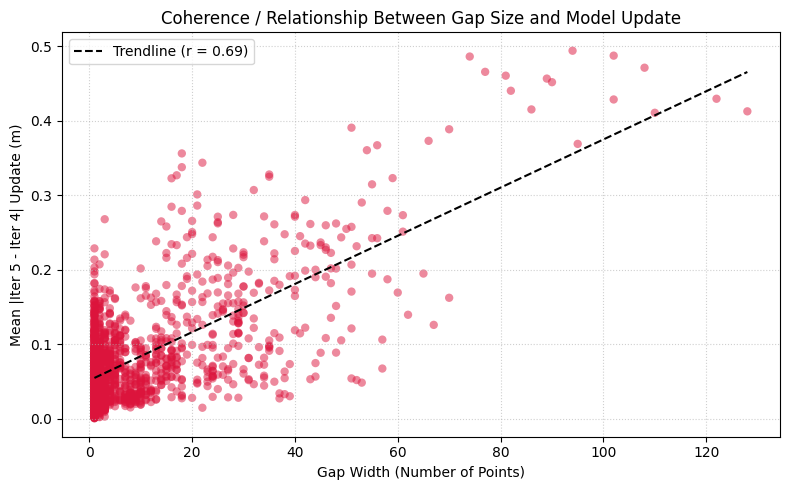

,timestep,gap_width,mean_abs_diff,max_abs_diff
0,0,4,0.053007,0.090392
1,0,17,0.156536,0.397627
2,0,4,0.115414,0.143992
3,0,1,0.116715,0.116715
4,0,1,0.112025,0.112025
...,...,...,...,...
1441,238,3,0.057841,0.069190
1442,238,10,0.035856,0.084320
1443,238,16,0.081989,0.203758
1444,238,3,0.267968,0.286601


In [87]:
analyze_gap_size_vs_difference(orig_full_df=transect_df_raw, recon1_df=it1, recon2_df=it2)

--- Gap Size vs. Model Update Correlation ---
Total Valid Gaps Analyzed: 1446
Pearson r  : 0.715 (p-value: 1.089e-226)
Spearman ρ : 0.674 (p-value: 5.025e-192)


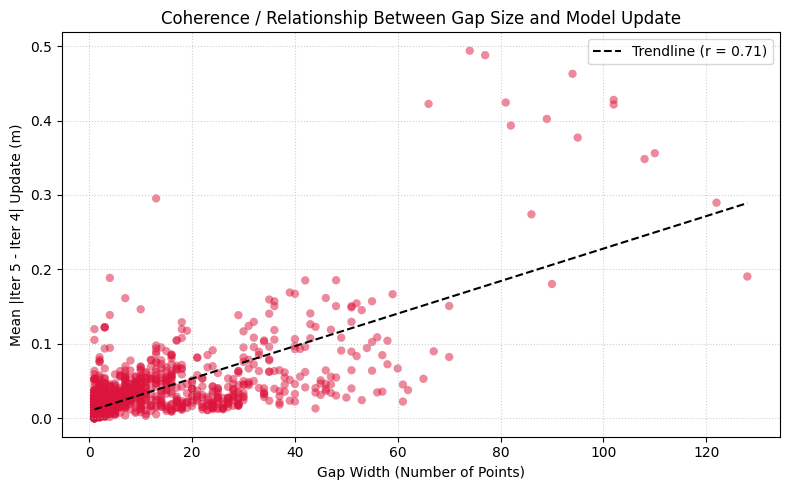

,timestep,gap_width,mean_abs_diff,max_abs_diff
0,0,4,0.008519,0.010768
1,0,17,0.104824,0.147387
2,0,4,0.022406,0.028255
3,0,1,0.013633,0.013633
4,0,1,0.002936,0.002936
...,...,...,...,...
1441,238,3,0.042512,0.078762
1442,238,10,0.047501,0.075261
1443,238,16,0.084087,0.130486
1444,238,3,0.007392,0.015066


In [88]:
analyze_gap_size_vs_difference(orig_full_df=transect_df_raw, recon1_df=it2, recon2_df=it3)

--- Gap Size vs. Model Update Correlation ---
Total Valid Gaps Analyzed: 1446
Pearson r  : 0.583 (p-value: 3.682e-132)
Spearman ρ : 0.447 (p-value: 4.802e-72)


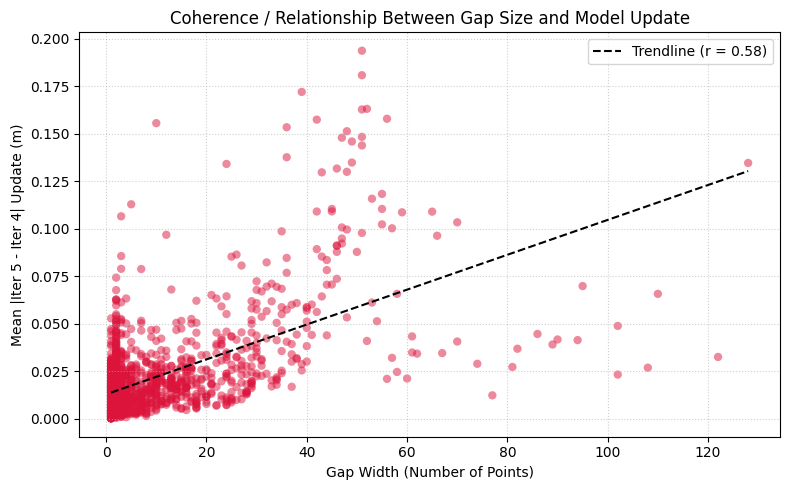

,timestep,gap_width,mean_abs_diff,max_abs_diff
0,0,4,0.012306,0.020075
1,0,17,0.021723,0.044640
2,0,4,0.006196,0.009124
3,0,1,0.022612,0.022612
4,0,1,0.016624,0.016624
...,...,...,...,...
1441,238,3,0.031250,0.057784
1442,238,10,0.027528,0.047567
1443,238,16,0.006437,0.010508
1444,238,3,0.001035,0.001959


In [89]:
analyze_gap_size_vs_difference(orig_full_df=transect_df_raw, recon1_df=it3, recon2_df=it4)

--- Gap Size vs. Model Update Correlation ---
Total Valid Gaps Analyzed: 1446
Pearson r  : 0.615 (p-value: 2.903e-151)
Spearman ρ : 0.639 (p-value: 1.761e-166)


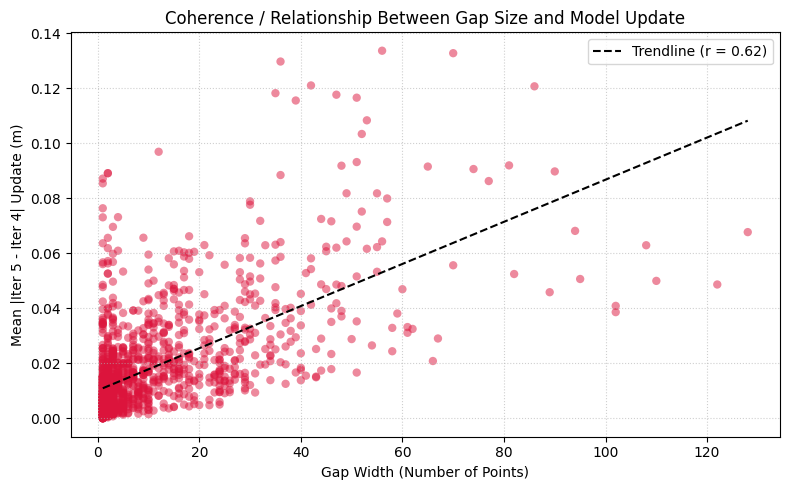

,timestep,gap_width,mean_abs_diff,max_abs_diff
0,0,4,0.011139,0.021624
1,0,17,0.053599,0.085489
2,0,4,0.015453,0.022114
3,0,1,0.012379,0.012379
4,0,1,0.001068,0.001068
...,...,...,...,...
1441,238,3,0.005329,0.006794
1442,238,10,0.003014,0.005022
1443,238,16,0.036740,0.056199
1444,238,3,0.001331,0.002361


In [90]:
analyze_gap_size_vs_difference(orig_full_df=transect_df_raw, recon1_df=it4, recon2_df=it5)